# Live Preprocessing v2


the order of this notebook:

1. audit logging,
2. data environment setup,
3. API key handling,
4. ENTSO-E data download,
5. data loading and checking,
6. visual inspection,
7. gap handling,
8. outlier detection,
9. missing-weight logic,
10. calendar features,
11. weather features,
12. feature merging,
13. model training,
14. feature importance,
15. forecast generation,
16. CSV validation,
17. baseline comparison,
18. backtesting,
19. provenance.

Important: this notebook is for testing. The official GitHub submission should still contain only the CSV file.

## Audit Logging

This section starts a persistent audit log for the live v2 pipeline.

The log records important pipeline events such as:

- target date,
- training window,
- data download path,
- preprocessing results,
- feature matrix shape,
- model training settings,
- forecast output path.


In [1]:
#| label: audit-log
#| echo: true

import logging
from pathlib import Path
from spotforecast2_safe.manager.logger import setup_logging

log_dir = Path("_cache/logs")
log_dir.mkdir(parents=True, exist_ok=True)

logger, log_path = setup_logging(level=logging.INFO, log_dir=log_dir)

logger.info("Live v2 load-forecasting pipeline starts.")

print(f"Log file: {log_path.name if log_path else '<stdout only>'}")

2026-06-19 23:39:00,653 - task_safe_n_to_1 - INFO - Persistent logging initialized at: _cache\logs\task_safe_n_to_1_20260619_233900.log
2026-06-19 23:39:00,655 - task_safe_n_to_1 - INFO - Live v2 load-forecasting pipeline starts.
Log file: task_safe_n_to_1_20260619_233900.log


d:\AIT\ddmo-sose-26\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Environment Preparation

This section prepares the local data folder and defines the live forecasting setup.

Unlike `start.ipynb`, this notebook does not use a fixed 2024 window.  
It uses a live target date and a training window from 2023 to the latest available data before the target day.

In [2]:
#| label: env-prep
#| echo: true

import os
from pathlib import Path
import pandas as pd

TEAM_ID = "neura"
COUNTRY = "DE"

# Explicit leaderboard repository path.
repo_root = Path(r"D:\AIT\challenge-leaderboard")

if not repo_root.exists():
    raise FileNotFoundError(f"Leaderboard repo not found: {repo_root}")

if not (repo_root / "submissions").exists():
    raise FileNotFoundError(
        f"This does not look like the challenge-leaderboard repo: {repo_root}"
    )

# Dynamic live target: tomorrow in UTC.
NOW_UTC = pd.Timestamp.now(tz="UTC")
TODAY_UTC = NOW_UTC.normalize()
TOMORROW_UTC = TODAY_UTC + pd.Timedelta(days=1)

TARGET_DATE = TOMORROW_UTC.date().isoformat()
target = TOMORROW_UTC.to_pydatetime()

# Keep data cache local to this notebook/project.
DATA_HOME = Path.cwd() / "_cache" / "spotforecast2_data"
DATA_HOME.mkdir(parents=True, exist_ok=True)
os.environ["SPOTFORECAST2_DATA"] = str(DATA_HOME)

# Download enough history for training.
DATA_START = "202401010000"

# Live download should reach now, not simply target - 1h.
DATA_END = NOW_UTC.strftime("%Y%m%d%H%M")

logger.info(f"Repo root: {repo_root}")
logger.info(f"Data home: {DATA_HOME}")
logger.info(f"Live ENTSO-E window: {DATA_START} to {DATA_END}")
logger.info(f"Team ID: {TEAM_ID}")
logger.info(f"Target date: {TARGET_DATE}")

print(f"Repo root: {repo_root}")
print(f"Data home: {DATA_HOME}")
print(f"Window:    {DATA_START} to {DATA_END}")
print(f"Country:   {COUNTRY}")
print(f"Team:      {TEAM_ID}")
print(f"Target:    {TARGET_DATE}")
print(f"Now UTC:   {NOW_UTC}")

2026-06-19 23:39:00,688 - task_safe_n_to_1 - INFO - Repo root: D:\AIT\challenge-leaderboard


2026-06-19 23:39:00,693 - task_safe_n_to_1 - INFO - Data home: d:\AIT\ddmo-sose-26\venv\_cache\spotforecast2_data
2026-06-19 23:39:00,697 - task_safe_n_to_1 - INFO - Live ENTSO-E window: 202401010000 to 202606192139
2026-06-19 23:39:00,702 - task_safe_n_to_1 - INFO - Team ID: neura
2026-06-19 23:39:00,707 - task_safe_n_to_1 - INFO - Target date: 2026-06-20
Repo root: D:\AIT\challenge-leaderboard
Data home: d:\AIT\ddmo-sose-26\venv\_cache\spotforecast2_data
Window:    202401010000 to 202606192139
Country:   DE
Team:      neura
Target:    2026-06-20
Now UTC:   2026-06-19 21:39:00.686483+00:00


## Load ENTSO-E API Key

This section loads the ENTSO-E API key from `api.env`.

The API key is needed to download live ENTSO-E load data.

In [3]:
#| label: load-api-key
#| echo: true

from dotenv import load_dotenv
import os
from pathlib import Path

load_dotenv(dotenv_path=Path("api.env"))

if os.getenv("ENTSOE_API_KEY"):
    logger.info("ENTSO-E API key loaded from api.env.")
    print("ENTSO-E API key loaded.")
else:
    logger.error("ENTSO-E API key was not found in api.env.")
    print("ENTSO-E API key was not found in api.env.")

2026-06-19 23:39:00,791 - task_safe_n_to_1 - INFO - ENTSO-E API key loaded from api.env.
ENTSO-E API key loaded.


## Load ENTSO-E Data with Incremental Cache

This section prepares the live ENTSO-E load series efficiently.

Instead of downloading the full historical range every time, the notebook first checks whether an hourly ENTSO-E cache already exists.

If a cache exists, it loads the cached hourly load data and downloads only the missing new hours up to the current target window.

If no cache exists, it downloads the full required range once and saves it as a parquet cache.

This replaces the older separate steps:

- download raw ENTSO-E data,
- load the interim CSV,
- resample to hourly values,
- persist the prepared load series.

The output of this section is the prepared hourly load series `y`, which is used by the following preprocessing steps.

In [4]:
#| label: load-entsoe-live
#| echo: true

import logging
import os
from pathlib import Path

import numpy as np
import pandas as pd

from spotforecast2_safe.downloader.entsoe import download_new_data
from spotforecast2_safe.data.fetch_data import fetch_data, get_data_home

logging.getLogger("spotforecast2_safe.downloader.entsoe").setLevel(logging.INFO)

shared = Path("_cache/shared")
shared.mkdir(parents=True, exist_ok=True)

api_key = os.environ.get("ENTSOE_API_KEY")

if not api_key:
    logger.error("ENTSOE_API_KEY is not set. Data download cannot continue.")
    raise RuntimeError("ENTSOE_API_KEY is not set. Check api.env.")

required_start = pd.to_datetime(DATA_START, format="%Y%m%d%H%M", utc=True)
required_end = pd.to_datetime(DATA_END, format="%Y%m%d%H%M", utc=True)

print("Required ENTSO-E download range:")
print("start:", required_start)
print("end:  ", required_end)

logger.info(f"ENTSO-E live download started: {required_start} to {required_end}")

download_new_data(
    api_key=api_key,
    country_code=COUNTRY,
    start=DATA_START,
    end=DATA_END,
    force=True,
)

interim = get_data_home() / "interim" / "energy_load.csv"

df_raw = fetch_data(filename=str(interim))
df_raw.index = pd.to_datetime(df_raw.index, utc=True)
df_raw = df_raw.sort_index()

print()
print("Raw ENTSO-E data:")
print("first:", df_raw.index.min())
print("last: ", df_raw.index.max())
print("columns:", df_raw.columns.tolist())
print("rows:", len(df_raw))

load_col = next(
    c for c in df_raw.columns
    if "Actual" in c and "Load" in c
)

y_raw = df_raw[load_col].astype(float).rename("load")

# Germany is often 15-minute resolution. Convert to hourly mean.
if y_raw.index.inferred_freq != "h":
    y_hourly = y_raw.resample("h").mean()
else:
    y_hourly = y_raw.copy()

# Important live rule:
# Use only actually published Actual Load values for training.
last_actual = y_hourly.dropna().index.max()

if pd.isna(last_actual):
    raise RuntimeError("No valid Actual Load values found in ENTSO-E data.")

LAST_FULL_HOUR = last_actual.floor("h")
FIRST_PRED = LAST_FULL_HOUR + pd.Timedelta(hours=1)
LAST_TARGET = TOMORROW_UTC + pd.Timedelta(hours=23)

LIVE_N_STEPS = int((LAST_TARGET - FIRST_PRED) / pd.Timedelta(hours=1)) + 1

if LIVE_N_STEPS < 24:
    raise RuntimeError(
        f"Live horizon too short: {LIVE_N_STEPS}. "
        "Check target date and ENTSO-E data range."
    )

# Training series only until last actually available full hour.
y = y_hourly.loc[required_start:LAST_FULL_HOUR].copy()
y = y.dropna()

# Ensure clean hourly frequency for the forecaster.
y = y.asfreq("h")

# Ensure hourly frequency.
# Important: do NOT fill or raise here.
# Missing values are handled explicitly in the preprocessing cells:
# mark_outliers -> get_missing_weights -> WeightFunction
y = y.asfreq("h")

missing = int(y.isna().sum())

if missing > 0:
    missing_preview = y[y.isna()].index[:10].tolist()
    print()
    print(f"Training series contains {missing} missing hourly values.")
    print("First missing timestamps:")
    for ts in missing_preview:
        print(" -", ts)

    logger.warning(
        f"Training series contains {missing} missing hourly values after asfreq(). "
        "These will be handled by the annotation/weight pipeline."
    )
else:
    logger.info("Training series has no missing hourly values after asfreq().")

y.to_frame("load").to_parquet(shared / "load_de_live_hourly.parquet")

logger.info(f"ENTSO-E raw file: {interim}")
logger.info(f"Actual load column: {load_col}")
logger.info(f"Last full actual hour: {LAST_FULL_HOUR}")
logger.info(f"First prediction hour: {FIRST_PRED}")
logger.info(f"Last target hour: {LAST_TARGET}")
logger.info(f"Live recursive steps: {LIVE_N_STEPS}")
logger.info(f"Training series rows: {len(y)}")

print()
print("Prepared hourly training series:")
print("first:", y.index.min())
print("last: ", y.index.max())
print("rows:", len(y))
print("NaN:", int(y.isna().sum()))
print("freq:", y.index.freq)

print()
print("Live forecast bridge:")
print("LAST_FULL_HOUR:", LAST_FULL_HOUR)
print("FIRST_PRED:     ", FIRST_PRED)
print("LAST_TARGET:    ", LAST_TARGET)
print("LIVE_N_STEPS:   ", LIVE_N_STEPS)

Required ENTSO-E download range:
start: 2024-01-01 00:00:00+00:00
end:   2026-06-19 21:39:00+00:00
2026-06-19 23:39:00,880 - task_safe_n_to_1 - INFO - ENTSO-E live download started: 2024-01-01 00:00:00+00:00 to 2026-06-19 21:39:00+00:00

Raw ENTSO-E data:
first: 2023-01-01 00:00:00+00:00
last:  2026-06-19 21:30:00+00:00
columns: ['Forecasted Load', 'Actual Load']
rows: 121525

Training series contains 6 missing hourly values.
First missing timestamps:
 - 2026-05-31 15:00:00+00:00
 - 2026-05-31 16:00:00+00:00
 - 2026-05-31 17:00:00+00:00
 - 2026-05-31 20:00:00+00:00
 - 2026-05-31 21:00:00+00:00
 - 2026-05-31 22:00:00+00:00
2026-06-19 23:43:36,751 - task_safe_n_to_1 - WARNING - Training series contains 6 missing hourly values after asfreq(). These will be handled by the annotation/weight pipeline.
2026-06-19 23:43:37,957 - task_safe_n_to_1 - INFO - ENTSO-E raw file: d:\AIT\ddmo-sose-26\venv\_cache\spotforecast2_data\interim\energy_load.csv
2026-06-19 23:43:37,959 - task_safe_n_to_1 - INF

## Check ENTSO-E Freshness and Frame Coverage

This step verifies that the live ENTSO-E input is usable before training.

First, it checks that the latest valid `Actual Load` value is not too old. Second, it checks that the downloaded raw ENTSO-E data frame reaches a recent timestamp. These checks prevent the pipeline from silently training on stale or incomplete input data.

In [5]:
#| label: check-entsoe-freshness-and-coverage
#| echo: true

MAX_ACTUAL_LAG = pd.Timedelta(hours=36)

# 1. Check latest valid Actual Load value.
actual_lag = NOW_UTC - LAST_FULL_HOUR

print("Actual Load freshness check:")
print("NOW_UTC:         ", NOW_UTC)
print("LAST_FULL_HOUR:  ", LAST_FULL_HOUR)
print("Actual lag:      ", actual_lag)
print("Max allowed lag: ", MAX_ACTUAL_LAG)

if actual_lag > MAX_ACTUAL_LAG:
    raise RuntimeError(
        f"Actual Load is stale: last published actual is {LAST_FULL_HOUR}, "
        f"which is {actual_lag} behind NOW_UTC. "
        f"Tolerance is {MAX_ACTUAL_LAG}."
    )

logger.info(f"Actual Load freshness check passed: lag={actual_lag}")

print()
print("Actual Load freshness check passed.")


# 2. Check raw ENTSO-E frame coverage.
required_last = TODAY_UTC - pd.Timedelta(hours=1)

print()
print("ENTSO-E frame coverage check:")
print("Frame first timestamp:", df_raw.index.min())
print("Frame last timestamp: ", df_raw.index.max())
print("Required at least:    ", required_last)

if df_raw.index.max() < required_last:
    raise RuntimeError(
        f"ENTSO-E frame coverage is stale: last row is {df_raw.index.max()}, "
        f"but required at least {required_last}."
    )

logger.info(f"ENTSO-E frame coverage check passed: last row={df_raw.index.max()}")

print()
print("ENTSO-E frame coverage check passed.")

Actual Load freshness check:
NOW_UTC:          2026-06-19 21:39:00.686483+00:00
LAST_FULL_HOUR:   2026-06-19 20:00:00+00:00
Actual lag:       0 days 01:39:00.686483
Max allowed lag:  1 days 12:00:00
2026-06-19 23:43:38,064 - task_safe_n_to_1 - INFO - Actual Load freshness check passed: lag=0 days 01:39:00.686483

Actual Load freshness check passed.

ENTSO-E frame coverage check:
Frame first timestamp: 2023-01-01 00:00:00+00:00
Frame last timestamp:  2026-06-19 21:30:00+00:00
Required at least:     2026-06-18 23:00:00+00:00
2026-06-19 23:43:38,071 - task_safe_n_to_1 - INFO - ENTSO-E frame coverage check passed: last row=2026-06-19 21:30:00+00:00

ENTSO-E frame coverage check passed.


## Check Missing Values

This section checks whether the prepared live load series contains missing values.

In `start.ipynb`, artificial gaps were inserted to demonstrate the gap-handling method.

In this live notebook, we do not insert artificial gaps into the training data. Instead, we check the real live data for missing values.

In [6]:
#| label: check-real-gaps
#| echo: true

n_missing = int(y.isna().sum())

logger.info(f"Real missing values in prepared live load series: {n_missing}")

print(f"Missing values in live load series: {n_missing}")

if n_missing > 0:
    missing_idx = y.index[y.isna()]

    print()
    print("First missing timestamps:")
    print(missing_idx[:10].tolist())

    print()
    print("Last missing timestamps:")
    print(missing_idx[-10:].tolist())

    first_missing = missing_idx[0]

    print()
    print("Window around first missing value:")
    print(y.loc[first_missing - pd.Timedelta(hours=3): first_missing + pd.Timedelta(hours=3)])
else:
    print("No missing values found. Gap interpolation is not needed for this run.")

2026-06-19 23:43:38,220 - task_safe_n_to_1 - INFO - Real missing values in prepared live load series: 6
Missing values in live load series: 6

First missing timestamps:
[Timestamp('2026-05-31 15:00:00+0000', tz='UTC'), Timestamp('2026-05-31 16:00:00+0000', tz='UTC'), Timestamp('2026-05-31 17:00:00+0000', tz='UTC'), Timestamp('2026-05-31 20:00:00+0000', tz='UTC'), Timestamp('2026-05-31 21:00:00+0000', tz='UTC'), Timestamp('2026-05-31 22:00:00+0000', tz='UTC')]

Last missing timestamps:
[Timestamp('2026-05-31 15:00:00+0000', tz='UTC'), Timestamp('2026-05-31 16:00:00+0000', tz='UTC'), Timestamp('2026-05-31 17:00:00+0000', tz='UTC'), Timestamp('2026-05-31 20:00:00+0000', tz='UTC'), Timestamp('2026-05-31 21:00:00+0000', tz='UTC'), Timestamp('2026-05-31 22:00:00+0000', tz='UTC')]

Window around first missing value:
Time (UTC)
2026-05-31 12:00:00+00:00    40781.880522
2026-05-31 13:00:00+00:00    41079.010497
2026-05-31 14:00:00+00:00    41108.226890
2026-05-31 15:00:00+00:00             NaN


## Create Clean Live Load Series

This section creates the clean live load series used for model training.

If real missing values exist, `LinearlyInterpolateTS` is applied with fail-safe behavior.

If no missing values exist, the series is copied unchanged.

The final clean series must contain no NaN values.

In [7]:
#| label: create-clean-live-series
#| echo: true

# Keep the raw hourly ENTSO-E series.
# Do not fill missing values here.
# The professor-style annotation pipeline will handle them later:
# mark_outliers -> get_missing_weights -> WeightFunction

y_live_raw = y.copy()
y_live_raw.index = pd.DatetimeIndex(y_live_raw.index, freq="h")

missing_raw = int(y_live_raw.isna().sum())

print("Raw live load series for annotation:")
print("first:", y_live_raw.index.min())
print("last: ", y_live_raw.index.max())
print("rows:", len(y_live_raw))
print("NaN before annotation:", missing_raw)
print("freq:", y_live_raw.index.freq)

logger.info(f"Raw live load series range: {y_live_raw.index.min()} to {y_live_raw.index.max()}")
logger.info(f"Raw live load rows: {len(y_live_raw):,}")
logger.info(f"Raw live load NaN values before annotation: {missing_raw}")

Raw live load series for annotation:
first: 2024-01-01 00:00:00+00:00
last:  2026-06-19 20:00:00+00:00
rows: 21621
NaN before annotation: 6
freq: <Hour>
2026-06-19 23:43:38,288 - task_safe_n_to_1 - INFO - Raw live load series range: 2024-01-01 00:00:00+00:00 to 2026-06-19 20:00:00+00:00
2026-06-19 23:43:38,290 - task_safe_n_to_1 - INFO - Raw live load rows: 21,621
2026-06-19 23:43:38,292 - task_safe_n_to_1 - INFO - Raw live load NaN values before annotation: 6


In [8]:
#| label: apply-quality-mask
#| echo: true

# Professor-reported faulty ENTSO-E / TenneT artefact period.
# These hours should not be trusted for training or clean validation.
FAULT_START = pd.Timestamp("2026-06-03 00:00:00", tz="UTC")
FAULT_END = pd.Timestamp("2026-06-05 23:00:00", tz="UTC")

target_quality_mask = pd.Series(True, index=y_live_raw.index)

target_quality_mask.loc[
    (target_quality_mask.index >= FAULT_START)
    & (target_quality_mask.index <= FAULT_END)
] = False

print("quality mask:")
print("fault start:", FAULT_START)
print("fault end:  ", FAULT_END)
print("total rows:", len(target_quality_mask))
print("masked rows:", int((~target_quality_mask).sum()))
print("clean rows:", int(target_quality_mask.sum()))

logger.info("quality mask created.")
logger.info(f"Fault period: {FAULT_START} to {FAULT_END}")
logger.info(f"Masked rows: {int((~target_quality_mask).sum())}")

quality mask:
fault start: 2026-06-03 00:00:00+00:00
fault end:   2026-06-05 23:00:00+00:00
total rows: 21621
masked rows: 72
clean rows: 21549
2026-06-19 23:43:38,341 - task_safe_n_to_1 - INFO - quality mask created.
2026-06-19 23:43:38,343 - task_safe_n_to_1 - INFO - Fault period: 2026-06-03 00:00:00+00:00 to 2026-06-05 23:00:00+00:00
2026-06-19 23:43:38,347 - task_safe_n_to_1 - INFO - Masked rows: 72


## Mark Real Outliers

This section applies the same outlier-marking logic used in `start.ipynb`.

In `start.ipynb`, an artificial spike was injected to demonstrate the method.

In this live notebook, no artificial spike is inserted. The method is applied directly to the real live load series.

Detected outliers are marked as `NaN` so they remain visible for the missing-weight step.

In [9]:
#| label: mark-real-outliers
#| echo: true

from spotforecast2_safe.preprocessing import mark_outliers

df_live = y_live_raw.to_frame("load")

df_marked, labels = mark_outliers(
    df_live.copy(),
    contamination=0.005,
    random_state=2026,
    verbose=True,
)

n_marked = int(df_marked["load"].isna().sum())

logger.info("Real outlier marking completed.")
logger.info(f"Marked rows: {n_marked} ({n_marked / len(df_marked):.2%})")

print(f"Marked rows: {n_marked} ({n_marked / len(df_marked):.2%})")

if n_marked > 0:
    marked_idx = df_marked.index[df_marked["load"].isna()]
    print()
    print("First marked timestamps:")
    print(marked_idx[:10].tolist())

    print()
    print("Last marked timestamps:")
    print(marked_idx[-10:].tolist())

Column 'load': Marked 0.5041% of data points as outliers.
2026-06-19 23:43:39,154 - task_safe_n_to_1 - INFO - Real outlier marking completed.
2026-06-19 23:43:39,155 - task_safe_n_to_1 - INFO - Marked rows: 115 (0.53%)
Marked rows: 115 (0.53%)

First marked timestamps:
[Timestamp('2024-01-15 10:00:00+0000', tz='UTC'), Timestamp('2024-03-31 02:00:00+0000', tz='UTC'), Timestamp('2024-03-31 03:00:00+0000', tz='UTC'), Timestamp('2024-03-31 04:00:00+0000', tz='UTC'), Timestamp('2024-04-01 01:00:00+0000', tz='UTC'), Timestamp('2024-05-12 00:00:00+0000', tz='UTC'), Timestamp('2024-05-12 01:00:00+0000', tz='UTC'), Timestamp('2024-05-12 02:00:00+0000', tz='UTC'), Timestamp('2024-05-12 03:00:00+0000', tz='UTC'), Timestamp('2024-05-19 01:00:00+0000', tz='UTC')]

Last marked timestamps:
[Timestamp('2026-02-04 17:00:00+0000', tz='UTC'), Timestamp('2026-02-05 07:00:00+0000', tz='UTC'), Timestamp('2026-02-05 08:00:00+0000', tz='UTC'), Timestamp('2026-02-05 09:00:00+0000', tz='UTC'), Timestamp('2026-0

## Create Filled Series and Training Weights

This section applies the missing-weight logic from `start.ipynb`.

After outliers are marked as `NaN`, the series is technically filled so lag features can be constructed.

At the same time, a weight vector is created:

- weight `1` means the timestamp is safe,
- weight `0` means the timestamp is affected by missing or outlier values.

The current model wrapper does not accept weights directly, but the weights are still useful for diagnostics and backtest filtering.

In [10]:
#| label: missing-weights-live
#| echo: true

from spotforecast2_safe.preprocessing import get_missing_weights, WeightFunction

WINDOW_SIZE = 168

df_filled, weights = get_missing_weights(
    df_marked.copy(),
    window_size=WINDOW_SIZE,
    verbose=True,
)

# Add quality mask to the existing annotation weights.
# Any known faulty hour receives zero weight.
weights = weights.copy()

mask_aligned = target_quality_mask.reindex(weights.index).fillna(False)
weights.loc[~mask_aligned] = 0

weight_func = WeightFunction(weights)

logger.info("Missing-weight preprocessing completed.")
logger.info(f"Filled rows: {len(df_filled):,}")
logger.info(f"NaN after filling: {int(df_filled['load'].isna().sum())}")
logger.info(f"Zero-weight rows: {int((weights == 0).sum())}")

print("Filled data:")
print("rows:", len(df_filled))
print("NaN after filling:", int(df_filled["load"].isna().sum()))

print()
print("Weights:")
print("total rows:", len(weights))
print("zero-weight rows:", int((weights == 0).sum()))
print("one-weight rows:", int((weights == 1).sum()))

zero_idx = weights.index[weights == 0]

if len(zero_idx) > 0:
    print()
    print("First zero-weight timestamps:")
    print(zero_idx[:10].tolist())

    print()
    print("Last zero-weight timestamps:")
    print(zero_idx[-10:].tolist())

print()
print(weight_func)

Number of rows with missing values: 115
Percentage of rows with missing values: 0.53%
missing_indices: DatetimeIndex(['2024-01-15 10:00:00+00:00', '2024-03-31 02:00:00+00:00',
               '2024-03-31 03:00:00+00:00', '2024-03-31 04:00:00+00:00',
               '2024-04-01 01:00:00+00:00', '2024-05-12 00:00:00+00:00',
               '2024-05-12 01:00:00+00:00', '2024-05-12 02:00:00+00:00',
               '2024-05-12 03:00:00+00:00', '2024-05-19 01:00:00+00:00',
               ...
               '2026-02-04 17:00:00+00:00', '2026-02-05 07:00:00+00:00',
               '2026-02-05 08:00:00+00:00', '2026-02-05 09:00:00+00:00',
               '2026-05-31 15:00:00+00:00', '2026-05-31 16:00:00+00:00',
               '2026-05-31 17:00:00+00:00', '2026-05-31 20:00:00+00:00',
               '2026-05-31 21:00:00+00:00', '2026-05-31 22:00:00+00:00'],
              dtype='datetime64[us, UTC]', name='Time (UTC)', length=115, freq=None)
Number of rows with missing weights after processing: 4382
Per

## Check WeightFunction Behaviour

This section checks whether the training-weight function works correctly.

The function should return low or zero weights for timestamps that are in the danger zone.

This follows the same idea as the `wrap`, `edge-case`, and `pickle` sections in `start.ipynb`.

In [11]:
#| label: check-weight-function-live
#| echo: true

import pickle

# Basic sample check
sample = df_filled.index[:5]

print("WeightFunction:")
print(weight_func)

print()
print(f"Weights for {sample[0]} ... {sample[-1]}:")
print(weight_func(sample))

logger.info("WeightFunction sample check completed.")
logger.info(str(weight_func))


# Edge-case check: timestamps with zero weight
zero_idx = weights.index[weights == 0]

if len(zero_idx) > 0:
    window_in_gap = zero_idx[:3]

    logger.info(f"Testing WeightFunction edge case on danger-zone index: {window_in_gap.tolist()}")
    logger.info(f"Return value for danger-zone window: {weight_func(window_in_gap)}")

    print()
    print("Index in danger zone:")
    print(window_in_gap.tolist())
    print("Return value:")
    print(weight_func(window_in_gap))
else:
    print()
    print("No zero-weight timestamps found.")


# Pickle round-trip check
raw = pickle.dumps(weight_func)
weight_func_restored = pickle.loads(raw)

original = weight_func(df_filled.index[:5])
restored = weight_func_restored(df_filled.index[:5])

identical = bool(np.array_equal(original, restored))

logger.info("WeightFunction pickling test completed.")
logger.info(f"Pickle restored weights identical: {identical}")

print()
print("Pickle test:")
print("Original :", original)
print("Restored :", restored)
print("Identical:", identical)

WeightFunction:
WeightFunction(weights_series with 21621 entries)

Weights for 2024-01-01 00:00:00+00:00 ... 2024-01-01 04:00:00+00:00:
[1. 1. 1. 1. 1.]
2026-06-19 23:43:39,320 - task_safe_n_to_1 - INFO - WeightFunction sample check completed.
2026-06-19 23:43:39,322 - task_safe_n_to_1 - INFO - WeightFunction(weights_series with 21621 entries)
2026-06-19 23:43:39,325 - task_safe_n_to_1 - INFO - Testing WeightFunction edge case on danger-zone index: [Timestamp('2024-01-15 10:00:00+0000', tz='UTC'), Timestamp('2024-01-15 11:00:00+0000', tz='UTC'), Timestamp('2024-01-15 12:00:00+0000', tz='UTC')]


WeightFunction: all sample weights for the requested index are zero (the window falls entirely within gap-penalty zones). Returning None so ForecasterRecursive uses uniform weighting.


2026-06-19 23:43:39,330 - task_safe_n_to_1 - INFO - Return value for danger-zone window: None


WeightFunction: all sample weights for the requested index are zero (the window falls entirely within gap-penalty zones). Returning None so ForecasterRecursive uses uniform weighting.



Index in danger zone:
[Timestamp('2024-01-15 10:00:00+0000', tz='UTC'), Timestamp('2024-01-15 11:00:00+0000', tz='UTC'), Timestamp('2024-01-15 12:00:00+0000', tz='UTC')]
Return value:
None
2026-06-19 23:43:39,371 - task_safe_n_to_1 - INFO - WeightFunction pickling test completed.
2026-06-19 23:43:39,373 - task_safe_n_to_1 - INFO - Pickle restored weights identical: True

Pickle test:
Original : [1. 1. 1. 1. 1.]
Restored : [1. 1. 1. 1. 1.]
Identical: True


## Final Training Target after Preprocessing

This section creates the final training target from the filled load series.

The series has:

- real load values where data is clean,
- technically filled values where outliers were marked,
- no NaN values.

The weight vector is kept for diagnostics and backtest filtering, but the current `ForecasterRecursiveLGBM.fit()` method does not accept weights directly.

In [12]:
#| label: final-training-target-live
#| echo: true

y_train_live = df_filled["load"].copy()
y_train_live.index = pd.DatetimeIndex(y_train_live.index, freq="h")

if y_train_live.isna().any():
    raise ValueError("Final training target still contains NaN values.")

# Safety check: weights must align exactly with the training target.
if not y_train_live.index.equals(weights.index):
    raise ValueError("Training target index and weights index do not match.")

zero_weight_rows = int((weights == 0).sum())
one_weight_rows = int((weights == 1).sum())

logger.info("Final training target created from df_filled after annotation preprocessing.")
logger.info(f"Final training target range: {y_train_live.index.min()} to {y_train_live.index.max()}")
logger.info(f"Final training target rows: {len(y_train_live):,}")
logger.info(f"Final training target NaN values: {int(y_train_live.isna().sum())}")
logger.info(f"Weight rows: {len(weights):,}")
logger.info(f"Zero-weight rows: {zero_weight_rows:,}")
logger.info(f"One-weight rows: {one_weight_rows:,}")

print("Final training target:")
print("source: df_filled['load']")
print("first:", y_train_live.index.min())
print("last: ", y_train_live.index.max())
print("rows:", len(y_train_live))
print("NaN:", int(y_train_live.isna().sum()))
print("freq:", y_train_live.index.freq)

print()
print("Training weights:")
print("rows:", len(weights))
print("index aligned:", y_train_live.index.equals(weights.index))
print("zero-weight rows:", zero_weight_rows)
print("one-weight rows:", one_weight_rows)
print("zero-weight share:", f"{zero_weight_rows / len(weights):.2%}")

2026-06-19 23:43:39,412 - task_safe_n_to_1 - INFO - Final training target created from df_filled after annotation preprocessing.
2026-06-19 23:43:39,416 - task_safe_n_to_1 - INFO - Final training target range: 2024-01-01 00:00:00+00:00 to 2026-06-19 20:00:00+00:00
2026-06-19 23:43:39,418 - task_safe_n_to_1 - INFO - Final training target rows: 21,621
2026-06-19 23:43:39,421 - task_safe_n_to_1 - INFO - Final training target NaN values: 0
2026-06-19 23:43:39,423 - task_safe_n_to_1 - INFO - Weight rows: 21,621
2026-06-19 23:43:39,426 - task_safe_n_to_1 - INFO - Zero-weight rows: 4,382
2026-06-19 23:43:39,428 - task_safe_n_to_1 - INFO - One-weight rows: 17,239
Final training target:
source: df_filled['load']
first: 2024-01-01 00:00:00+00:00
last:  2026-06-19 20:00:00+00:00
rows: 21621
NaN: 0
freq: <Hour>

Training weights:
rows: 21621
index aligned: True
zero-weight rows: 4382
one-weight rows: 17239
zero-weight share: 20.27%


## Load and Weather Relationship

This section visualizes the relationship between electrical load and temperature over the last week of the training data.

The plot is used as a diagnostic check to see whether weather features may help the model explain load behaviour.

Weather rebuilt from cache:
first: 2023-01-01 00:00:00+00:00
last:  2026-06-20 23:00:00+00:00
shape: (30408, 42)
NaN: 7776


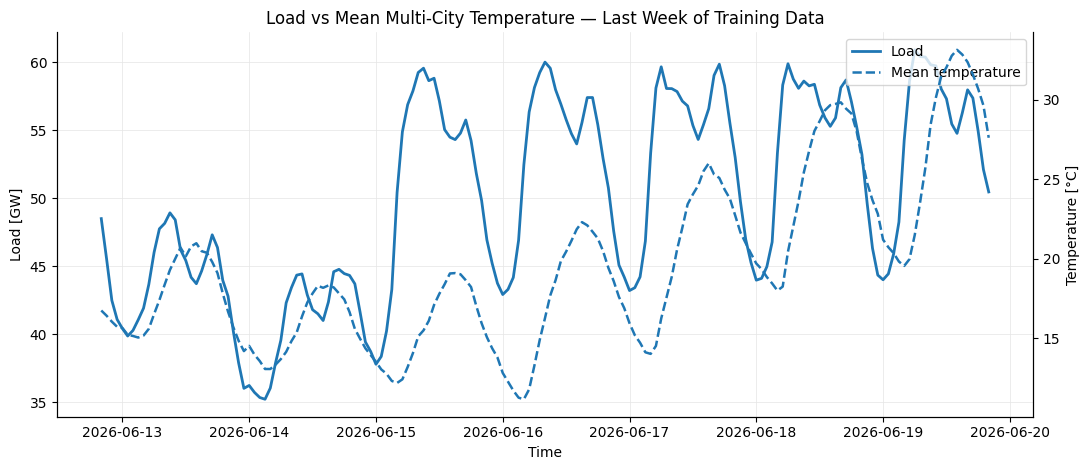

In [13]:
#| label: plot-load-weather-live
#| echo: true

import matplotlib.pyplot as plt
from pathlib import Path

# If weather is not currently in memory, rebuild it from cached city weather files.
if "weather" not in globals():
    weather_cache_files = sorted(Path("_cache/shared").glob("weather_*_live.parquet"))

    if not weather_cache_files:
        raise FileNotFoundError(
            "No cached weather files found. Run the fetch-weather-live cell first."
        )

    weather_frames = []

    for path in weather_cache_files:
        city_name = path.stem.replace("weather_", "").replace("_live", "")

        df_city = pd.read_parquet(path)
        df_city.index = pd.to_datetime(df_city.index, utc=True)
        df_city = df_city.sort_index()

        # If columns are not already prefixed, prefix them with city name.
        if not all(c.startswith(f"{city_name}_") for c in df_city.columns):
            df_city = df_city.add_prefix(f"{city_name}_")

        weather_frames.append(df_city)

    weather = pd.concat(weather_frames, axis=1)
    weather = weather[~weather.index.duplicated(keep="last")]
    weather = weather.sort_index()

    print("Weather rebuilt from cache:")
    print("first:", weather.index.min())
    print("last: ", weather.index.max())
    print("shape:", weather.shape)
    print("NaN:", int(weather.isna().sum().sum()))

last_week_start = y_train_live.index.max() - pd.Timedelta(days=7)

load_last_week = y_train_live.loc[last_week_start:]
weather_last_week = weather.reindex(load_last_week.index)

temp_cols = [c for c in weather_last_week.columns if c.endswith("temperature_2m")]

if not temp_cols:
    raise ValueError("No temperature_2m columns found in weather data.")

temperature_mean = weather_last_week[temp_cols].mean(axis=1)

fig, ax1 = plt.subplots(figsize=(11, 4.8))

ax1.plot(
    load_last_week.index,
    load_last_week.values / 1000,
    linewidth=2.0,
    label="Load",
)

ax1.set_ylabel("Load [GW]")
ax1.set_xlabel("Time")
ax1.grid(True, color="#E5E5E5", linewidth=0.5)

ax2 = ax1.twinx()

ax2.plot(
    temperature_mean.index,
    temperature_mean.values,
    linestyle="--",
    linewidth=1.8,
    label="Mean temperature",
)

ax2.set_ylabel("Temperature [°C]")

ax1.set_title("Load vs Mean Multi-City Temperature — Last Week of Training Data")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")

for s in ("top",):
    ax1.spines[s].set_visible(False)
    ax2.spines[s].set_visible(False)

fig.tight_layout()
plt.show()

## Build Calendar Features

This section creates calendar features for the live model.

The same calendar-feature logic from `start.ipynb` is used:

- hour of day,
- day of week,
- month,
- German calendar context through `country_code="DE"`.

The feature matrix must cover both the training period and the forecast horizon.

In [14]:
#| label: calendar-features-live
#| echo: true

from spotforecast2_safe import Period, ExogBuilder

# Live recursive horizon:
# starts at first unknown hour and ends at tomorrow 23:00 UTC.
horizon = pd.date_range(FIRST_PRED, LAST_TARGET, freq="h", tz="UTC")

# Submission target:
# exactly tomorrow 00:00–23:00 UTC.
target_hours = pd.date_range(TOMORROW_UTC, LAST_TARGET, freq="h", tz="UTC")

periods = [
    Period(name="hour",      n_periods=12, column="hour",      input_range=(0, 23)),
    Period(name="dayofweek", n_periods=4,  column="dayofweek", input_range=(0,  6)),
    Period(name="month",     n_periods=12, column="month",     input_range=(1, 12)),
]
builder = ExogBuilder(periods=periods, country_code=COUNTRY)

exog_cal = builder.build(
    y_train_live.index.min(),
    horizon[-1],
)

logger.info(f"Calendar feature matrix created: {exog_cal.shape}")
logger.info(f"Calendar feature NaN values: {int(exog_cal.isna().sum().sum())}")

print("Calendar feature matrix:")
print("first:", exog_cal.index.min())
print("last: ", exog_cal.index.max())
print("shape:", exog_cal.shape)
print("NaN:", int(exog_cal.isna().sum().sum()))
print("First columns:", exog_cal.columns[:10].tolist())

print()
print("Forecast horizon:")
print("first:", horizon[0])
print("last: ", horizon[-1])
print("steps:", len(horizon))

print()
print("Submission target hours:")
print("first:", target_hours[0])
print("last: ", target_hours[-1])
print("rows:", len(target_hours))

if len(target_hours) != 24:
    raise ValueError(f"target_hours must have 24 rows, got {len(target_hours)}.")

if exog_cal.isna().any().any():
    raise ValueError("Calendar feature matrix contains NaN values.")

2026-06-19 23:43:46,258 - task_safe_n_to_1 - INFO - Calendar feature matrix created: (21648, 30)
2026-06-19 23:43:46,264 - task_safe_n_to_1 - INFO - Calendar feature NaN values: 0
Calendar feature matrix:
first: 2024-01-01 00:00:00+00:00
last:  2026-06-20 23:00:00+00:00
shape: (21648, 30)
NaN: 0
First columns: ['hour_0', 'hour_1', 'hour_2', 'hour_3', 'hour_4', 'hour_5', 'hour_6', 'hour_7', 'hour_8', 'hour_9']

Forecast horizon:
first: 2026-06-19 21:00:00+00:00
last:  2026-06-20 23:00:00+00:00
steps: 27

Submission target hours:
first: 2026-06-20 00:00:00+00:00
last:  2026-06-20 23:00:00+00:00
rows: 24


## Check Weekend and Holiday Features

This step checks whether the exogenous calendar matrix contains enough calendar information for the live load forecast.

The model should understand regular weekly patterns, because electricity demand is different on weekdays and weekends. This is mainly handled through the `dayofweek` calendar features created by `ExogBuilder`.

Public holidays can also strongly change load behaviour. A holiday can look like a normal weekday in the timestamp, but the electricity demand may be closer to a Sunday or weekend pattern. Therefore, this cell checks whether an explicit holiday feature, such as `is_holiday`, exists in the generated calendar features.

If a holiday column exists, the model can use it directly. If no holiday column exists, the model still has weekday/weekend information, but it does not have a direct public-holiday flag yet. In that case, a separate holiday feature should be added later.

In [15]:
#| label: check-holiday-features
#| echo: true

holiday_cols = [c for c in exog_cal.columns if "holiday" in c.lower()]
week_cols = [c for c in exog_cal.columns if "dayofweek" in c.lower()]

print("Day-of-week columns:")
print(week_cols)

print()
print("Holiday columns:")
print(holiday_cols)

if holiday_cols:
    print()
    print("Holiday feature exists.")
    print(exog_cal[holiday_cols].sum())
else:
    print()
    print("No explicit holiday feature found.")
    print("The model has weekday/weekend information, but no direct holiday flag yet.")

Day-of-week columns:
['dayofweek_0', 'dayofweek_1', 'dayofweek_2', 'dayofweek_3']

Holiday columns:
['holidays']

Holiday feature exists.
holidays    576
dtype: int64


Calendar feature plot window:
first: 2026-06-18 21:00:00+00:00
last:  2026-06-20 23:00:00+00:00
rows: 51

Hour columns: 12
Day-of-week columns: 4
Month columns: 12
Holiday columns: ['holidays']


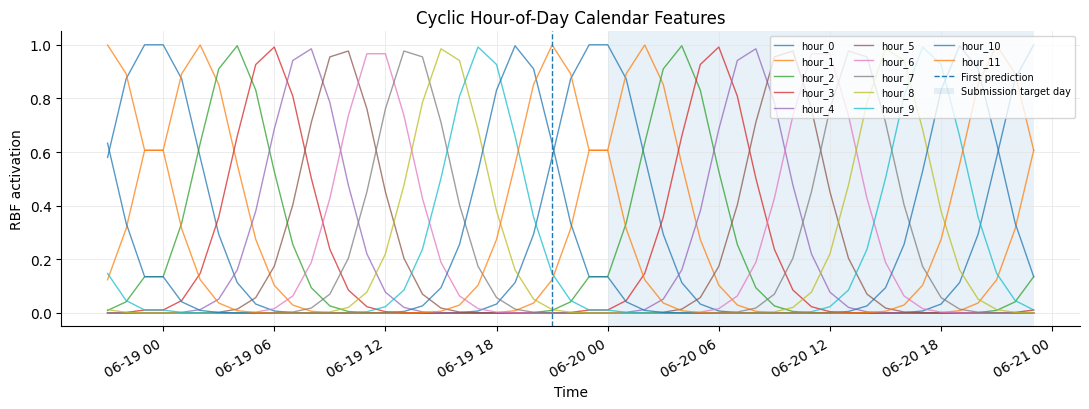

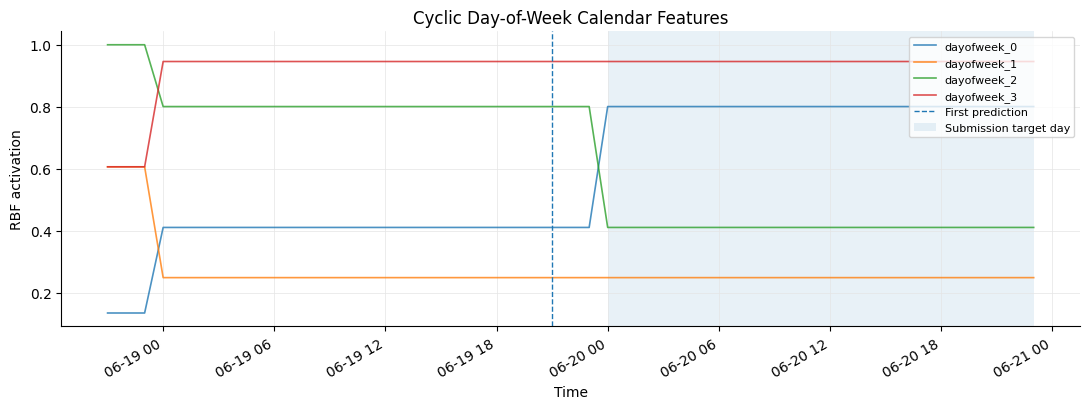

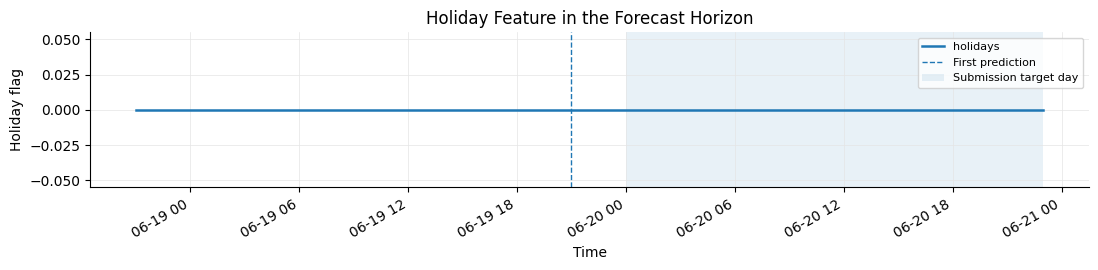

In [16]:
#| label: plot-cyclic-calendar-features
#| echo: true

import matplotlib.pyplot as plt

# Select cyclic calendar feature columns.
# ExogBuilder creates columns such as hour_0, hour_1, dayofweek_0, month_0, etc.
hour_cols = [c for c in exog_cal.columns if c.startswith("hour_")]
dow_cols = [c for c in exog_cal.columns if c.startswith("dayofweek_")]
month_cols = [c for c in exog_cal.columns if c.startswith("month_")]
holiday_cols = [c for c in exog_cal.columns if "holiday" in c.lower()]

# Plot a compact window around the live forecast horizon.
plot_start = FIRST_PRED - pd.Timedelta(hours=24)
plot_end = LAST_TARGET

calendar_window = exog_cal.loc[plot_start:plot_end]

print("Calendar feature plot window:")
print("first:", calendar_window.index.min())
print("last: ", calendar_window.index.max())
print("rows:", len(calendar_window))

print()
print("Hour columns:", len(hour_cols))
print("Day-of-week columns:", len(dow_cols))
print("Month columns:", len(month_cols))
print("Holiday columns:", holiday_cols)

if calendar_window.empty:
    raise ValueError("Calendar feature plot window is empty.")

# 1) Hour-of-day cyclic encoding
fig, ax = plt.subplots(figsize=(11, 4.2))

for c in hour_cols:
    ax.plot(
        calendar_window.index,
        calendar_window[c],
        linewidth=1.0,
        alpha=0.75,
        label=c,
    )

ax.axvline(FIRST_PRED, linestyle="--", linewidth=1.0, label="First prediction")
ax.axvspan(TOMORROW_UTC, LAST_TARGET, alpha=0.10, label="Submission target day")

ax.set_title("Cyclic Hour-of-Day Calendar Features")
ax.set_xlabel("Time")
ax.set_ylabel("RBF activation")
ax.grid(True, color="#E5E5E5", linewidth=0.5)

for s in ("top", "right"):
    ax.spines[s].set_visible(False)

ax.legend(loc="upper right", fontsize=7, ncol=3)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

# 2) Day-of-week cyclic encoding
fig, ax = plt.subplots(figsize=(11, 4.2))

for c in dow_cols:
    ax.plot(
        calendar_window.index,
        calendar_window[c],
        linewidth=1.2,
        alpha=0.8,
        label=c,
    )

ax.axvline(FIRST_PRED, linestyle="--", linewidth=1.0, label="First prediction")
ax.axvspan(TOMORROW_UTC, LAST_TARGET, alpha=0.10, label="Submission target day")

ax.set_title("Cyclic Day-of-Week Calendar Features")
ax.set_xlabel("Time")
ax.set_ylabel("RBF activation")
ax.grid(True, color="#E5E5E5", linewidth=0.5)

for s in ("top", "right"):
    ax.spines[s].set_visible(False)

ax.legend(loc="upper right", fontsize=8)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

# 3) Holiday feature, if available
if holiday_cols:
    fig, ax = plt.subplots(figsize=(11, 2.8))

    holiday_col = holiday_cols[0]

    ax.step(
        calendar_window.index,
        calendar_window[holiday_col],
        where="post",
        linewidth=1.8,
        label=holiday_col,
    )

    ax.axvline(FIRST_PRED, linestyle="--", linewidth=1.0, label="First prediction")
    ax.axvspan(TOMORROW_UTC, LAST_TARGET, alpha=0.10, label="Submission target day")

    ax.set_title("Holiday Feature in the Forecast Horizon")
    ax.set_xlabel("Time")
    ax.set_ylabel("Holiday flag")
    ax.grid(True, color="#E5E5E5", linewidth=0.5)

    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

    ax.legend(loc="upper right", fontsize=8)
    fig.autofmt_xdate()
    fig.tight_layout()
    plt.show()
else:
    print("No holiday column found; skipping holiday plot.")

## Fetch Weather Features

This section fetches weather features for the live model.

For past timestamps, historical archive weather is used.

For the target day, forecast weather is used because actual future weather is not available yet.

The weather data must cover the full period from the first training timestamp to the last target-hour timestamp.

In [17]:
#| label: fetch-weather-live
#| echo: true

import requests
import time

WEATHER_LOCATIONS = {
    "frankfurt": {"latitude": 50.110924, "longitude": 8.682127},
    "berlin": {"latitude": 52.520008, "longitude": 13.404954},
    "hamburg": {"latitude": 53.551086, "longitude": 9.993682},
    "munich": {"latitude": 48.135125, "longitude": 11.581981},
}

WEATHER_COLUMNS = [
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "cloud_cover",
    "wind_speed_10m",
    "wind_direction_10m",
]

weather_start = y_train_live.index.min().date()
weather_end = LAST_TARGET.date()

print("Required weather range:")
print("start:", weather_start)
print("end:  ", weather_end)


def fetch_open_meteo_range(latitude, longitude, start_date, end_date, forecast=False):
    url = (
        "https://api.open-meteo.com/v1/forecast"
        if forecast
        else "https://archive-api.open-meteo.com/v1/archive"
    )

    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": str(start_date),
        "end_date": str(end_date),
        "hourly": ",".join(WEATHER_COLUMNS),
        "timezone": "UTC",
    }

    response = requests.get(url, params=params, timeout=120)
    response.raise_for_status()

    data = response.json()["hourly"]

    df_weather = pd.DataFrame(data)
    df_weather["time"] = pd.to_datetime(df_weather["time"], utc=True)
    df_weather = df_weather.set_index("time")

    return df_weather


def load_or_update_city_weather(city_name, latitude, longitude):
    weather_cache_path = shared / f"weather_{city_name}_live.parquet"

    weather_parts = []

    if weather_cache_path.exists():
        weather_cached = pd.read_parquet(weather_cache_path)
        weather_cached.index = pd.to_datetime(weather_cached.index, utc=True)
        weather_cached = weather_cached[WEATHER_COLUMNS]
        weather_cached = weather_cached.sort_index()

        print()
        print(f"Weather cache found for {city_name}:")
        print("cache first:", weather_cached.index.min())
        print("cache last: ", weather_cached.index.max())
        print("cache rows: ", len(weather_cached))

        weather_parts.append(weather_cached)
    else:
        print()
        print(f"No weather cache found for {city_name}.")

    if weather_parts:
        cached_all = pd.concat(weather_parts)
        cached_all = cached_all[~cached_all.index.duplicated(keep="last")]
        cached_all = cached_all.sort_index()

        cached_first = cached_all.index.min().date()
        cached_last = cached_all.index.max().date()
    else:
        cached_all = pd.DataFrame(columns=WEATHER_COLUMNS)
        cached_first = None
        cached_last = None

    today_utc = pd.Timestamp.now(tz="UTC").date()
    archive_limit = today_utc - pd.Timedelta(days=1)

    missing_ranges = []

    if cached_first is None:
        missing_ranges.append((weather_start, min(weather_end, archive_limit), False))
    else:
        if weather_start < cached_first:
            missing_ranges.append(
                (
                    weather_start,
                    min(cached_first - pd.Timedelta(days=1), archive_limit),
                    False,
                )
            )

        if cached_last < min(weather_end, archive_limit):
            missing_ranges.append(
                (
                    cached_last + pd.Timedelta(days=1),
                    min(weather_end, archive_limit),
                    False,
                )
            )

    # Always refresh today/future forecast because forecasts can change.
    forecast_start = max(weather_start, today_utc)
    forecast_end = weather_end

    if forecast_start <= forecast_end:
        missing_ranges.append((forecast_start, forecast_end, True))

    for start_date, end_date, is_forecast in missing_ranges:
        if start_date > end_date:
            continue

        if is_forecast:
            print(f"Fetching forecast weather for {city_name}: {start_date} to {end_date}")

            part = fetch_open_meteo_range(
                latitude=latitude,
                longitude=longitude,
                start_date=start_date,
                end_date=end_date,
                forecast=True,
            )

            weather_parts.append(part)

        else:
            chunk_start = pd.Timestamp(start_date)

            while chunk_start.date() <= end_date:
                chunk_end = min(
                    chunk_start + pd.offsets.MonthEnd(0),
                    pd.Timestamp(end_date),
                )

                print(
                    f"Fetching archive weather for {city_name}: "
                    f"{chunk_start.date()} to {chunk_end.date()}"
                )

                part = fetch_open_meteo_range(
                    latitude=latitude,
                    longitude=longitude,
                    start_date=chunk_start.date(),
                    end_date=chunk_end.date(),
                    forecast=False,
                )

                weather_parts.append(part)

                chunk_start = chunk_end + pd.Timedelta(days=1)
                time.sleep(0.2)

    weather_city = pd.concat(weather_parts)
    weather_city = weather_city[~weather_city.index.duplicated(keep="last")]
    weather_city = weather_city.sort_index()
    weather_city = weather_city[WEATHER_COLUMNS]

    weather_city.to_parquet(weather_cache_path)

    weather_city = weather_city.loc[
    y_train_live.index.min(): LAST_TARGET
]

    # Prefix columns with city name.
    weather_city = weather_city.add_prefix(f"{city_name}_")

    print(f"{city_name} weather shape:", weather_city.shape)

    return weather_city


weather_city_frames = []

for city_name, location in WEATHER_LOCATIONS.items():
    weather_city = load_or_update_city_weather(
        city_name=city_name,
        latitude=location["latitude"],
        longitude=location["longitude"],
    )

    weather_city_frames.append(weather_city)


weather = pd.concat(weather_city_frames, axis=1)
weather = weather.sort_index()

print()
print("Multi-city weather feature matrix:")
print("first:", weather.index.min())
print("last: ", weather.index.max())
print("shape:", weather.shape)
print("NaN:", int(weather.isna().sum().sum()))

if weather.isna().any().any():
    raise ValueError("Multi-city weather feature matrix contains NaN values.")

logger.info(f"Multi-city weather feature matrix created: {weather.shape}")
logger.info(f"Multi-city weather NaN values: {int(weather.isna().sum().sum())}")

Required weather range:
start: 2024-01-01
end:   2026-06-20

Weather cache found for frankfurt:
cache first: 2023-01-01 00:00:00+00:00
cache last:  2026-06-20 23:00:00+00:00
cache rows:  30408
Fetching forecast weather for frankfurt: 2026-06-19 to 2026-06-20
frankfurt weather shape: (21648, 6)

Weather cache found for berlin:
cache first: 2023-01-01 00:00:00+00:00
cache last:  2026-06-20 23:00:00+00:00
cache rows:  30408
Fetching forecast weather for berlin: 2026-06-19 to 2026-06-20
berlin weather shape: (21648, 6)

Weather cache found for hamburg:
cache first: 2023-01-01 00:00:00+00:00
cache last:  2026-06-20 23:00:00+00:00
cache rows:  30408
Fetching forecast weather for hamburg: 2026-06-19 to 2026-06-20
hamburg weather shape: (21648, 6)

Weather cache found for munich:
cache first: 2023-01-01 00:00:00+00:00
cache last:  2026-06-20 23:00:00+00:00
cache rows:  30408
Fetching forecast weather for munich: 2026-06-19 to 2026-06-20
munich weather shape: (21648, 6)

Multi-city weather feat

## Add Weather-Derived Features

This section creates additional weather features from the raw multi-city weather data.

Electricity load often reacts nonlinearly to temperature, so heating-degree and cooling-degree features can help the model.

In [18]:
#| label: weather-derived-features-live
#| echo: true

temperature_cols = [c for c in weather.columns if c.endswith("temperature_2m")]

weather["temperature_mean_de"] = weather[temperature_cols].mean(axis=1)
weather["temperature_min_de"] = weather[temperature_cols].min(axis=1)
weather["temperature_max_de"] = weather[temperature_cols].max(axis=1)
weather["temperature_spread_de"] = (
    weather["temperature_max_de"] - weather["temperature_min_de"]
)

weather["heating_degree_15"] = np.maximum(0, 15 - weather["temperature_mean_de"])
weather["cooling_degree_22"] = np.maximum(0, weather["temperature_mean_de"] - 22)

humidity_cols = [c for c in weather.columns if c.endswith("relative_humidity_2m")]
cloud_cols = [c for c in weather.columns if c.endswith("cloud_cover")]
wind_cols = [c for c in weather.columns if c.endswith("wind_speed_10m")]
precip_cols = [c for c in weather.columns if c.endswith("precipitation")]

weather["humidity_mean_de"] = weather[humidity_cols].mean(axis=1)
weather["cloud_cover_mean_de"] = weather[cloud_cols].mean(axis=1)
weather["wind_speed_mean_de"] = weather[wind_cols].mean(axis=1)
weather["precipitation_mean_de"] = weather[precip_cols].mean(axis=1)

print("Weather with derived features:")
print("shape:", weather.shape)
print("NaN:", int(weather.isna().sum().sum()))

if weather.isna().any().any():
    raise ValueError("Weather-derived feature matrix contains NaN values.")

Weather with derived features:
shape: (21648, 34)
NaN: 0


## Weather Window Features

The basic weather features describe the current hour only. Electricity load can also depend on recent weather history, for example whether the last day was cold, warm, windy, or cloudy.

This step adds simple rolling weather-window features over the last 24 hours. These features are created only from weather variables, not from future actual load, so they do not leak the target. The features are included only if the backtest MAE improves.

## Weather Window Feature Experiment

As an additional experiment, rolling 24-hour weather-window features were tested. The idea was that electricity load might depend not only on the current weather, but also on recent weather history, for example the average temperature, cloud cover, wind, or heating/cooling demand over the previous 24 hours.

The tested weather-window features included rolling means, rolling maximum values, and 24-hour changes for national weather variables such as temperature, heating degree, cooling degree, humidity, cloud cover, wind speed, and precipitation.

However, the 7-day chronological backtest showed that these additional features did not improve the model. The mean MAE increased from about **1,385.5 MW** to **1,559.7 MW**, and the mean MAPE increased from about **2.97%** to **3.22%**. The number of days where the model beat weekly persistence also decreased from **5/7** to **4/7**.

Therefore, the weather-window features were not used in the final submission pipeline. The final model keeps the simpler weather feature set, because it performs better in the rolling 7-day backtest and avoids unnecessary feature complexity.

6/2

## Merge Calendar and Weather Features

This section joins the calendar feature matrix and the weather feature matrix.

The result is one full exogenous feature matrix used by the forecasting model.

It must cover the full training period and the full prediction horizon.

In [19]:
#| label: merge-exog-live
#| echo: true

exog = exog_cal.join(weather, how="inner")

exog = exog.loc[
    y_train_live.index.min(): LAST_TARGET
]

if exog.index.max() < LAST_TARGET:
    raise ValueError(
        f"Exogenous features end at {exog.index.max()}, but must cover LAST_TARGET {LAST_TARGET}."
    )

logger.info(f"Joined live feature matrix: {exog.shape}")
logger.info(f"Joined live feature NaN values: {int(exog.isna().sum().sum())}")

print(f"Joined feature matrix: {exog.shape[0]:,} hours, {exog.shape[1]} columns")
print(f"NaN values:            {int(exog.isna().sum().sum())}")

print()
print("Calendar columns:", exog_cal.shape[1])
print("Weather columns:", weather.shape[1])
print("Total columns:", exog.shape[1])

if exog.isna().any().any():
    raise ValueError("Joined exogenous feature matrix contains NaN values.")

exog.to_parquet(shared / "exog_live.parquet")

print("Saved `exog_live.parquet` for follow-up sections.")

2026-06-19 23:43:54,958 - task_safe_n_to_1 - INFO - Joined live feature matrix: (21648, 64)
2026-06-19 23:43:54,974 - task_safe_n_to_1 - INFO - Joined live feature NaN values: 0
Joined feature matrix: 21,648 hours, 64 columns
NaN values:            0

Calendar columns: 30
Weather columns: 34
Total columns: 64
Saved `exog_live.parquet` for follow-up sections.


In [20]:
#| label: add-safe-rolling-load-statistics
#| echo: true

# Original model mode:
# Rolling-load statistics were tested as an experiment, but they are disabled here.
# This cell intentionally does not modify `exog`.

print("Rolling-load statistics experiment is disabled. Using original exog features.")
logger.info("Rolling-load statistics experiment disabled. Original exog feature set kept.")


Rolling-load statistics experiment is disabled. Using original exog features.
2026-06-19 23:43:55,228 - task_safe_n_to_1 - INFO - Rolling-load statistics experiment disabled. Original exog feature set kept.


## Align Training and Prediction Features

This section splits the full exogenous feature matrix into:

1. training features with the same timestamps as the final training target,
2. prediction features from the hour after the last available actual load until the last target-hour.

The prediction horizon can be longer than 24 hours if the latest actual load is earlier than the target day.

In [21]:
#| label: align-exog-live
#| echo: true

# Original alignment:
# Training features must align exactly with the final filled training target.
train_exog = exog.loc[y_train_live.index]

# Prediction features must cover the complete recursive live horizon:
# FIRST_PRED -> LAST_TARGET.
prediction_start = FIRST_PRED
prediction_end = LAST_TARGET

prediction_exog = exog.loc[prediction_start:prediction_end]

horizon = LIVE_N_STEPS

logger.info(f"Training exog shape: {train_exog.shape}")
logger.info(f"Prediction exog shape: {prediction_exog.shape}")
logger.info(f"Prediction horizon: {horizon}")
logger.info(f"Prediction start: {prediction_start}")
logger.info(f"Prediction end: {prediction_end}")

print("Training exog:")
print("first:", train_exog.index.min())
print("last: ", train_exog.index.max())
print("shape:", train_exog.shape)
print("NaN:", int(train_exog.isna().sum().sum()))

print()
print("Prediction exog:")
print("first:", prediction_exog.index.min())
print("last: ", prediction_exog.index.max())
print("shape:", prediction_exog.shape)
print("NaN:", int(prediction_exog.isna().sum().sum()))

print()
print("Prediction horizon:", horizon)
print("Prediction exog rows:", len(prediction_exog))

if not train_exog.index.equals(y_train_live.index):
    raise ValueError("Training exog index does not match y_train_live index.")

if prediction_exog.index.min() != FIRST_PRED:
    raise ValueError(
        f"Prediction exog starts at {prediction_exog.index.min()}, "
        f"but expected FIRST_PRED {FIRST_PRED}."
    )

if prediction_exog.index.max() != LAST_TARGET:
    raise ValueError(
        f"Prediction exog ends at {prediction_exog.index.max()}, "
        f"but expected LAST_TARGET {LAST_TARGET}."
    )

if len(prediction_exog) != horizon:
    raise ValueError("Prediction exog rows do not match LIVE_N_STEPS.")

if train_exog.isna().any().any():
    raise ValueError("Training exog contains NaN.")

if prediction_exog.isna().any().any():
    raise ValueError("Prediction exog contains NaN.")

print()
print("Alignment checks passed.")


2026-06-19 23:43:55,291 - task_safe_n_to_1 - INFO - Training exog shape: (21621, 64)


2026-06-19 23:43:55,298 - task_safe_n_to_1 - INFO - Prediction exog shape: (27, 64)
2026-06-19 23:43:55,302 - task_safe_n_to_1 - INFO - Prediction horizon: 27
2026-06-19 23:43:55,305 - task_safe_n_to_1 - INFO - Prediction start: 2026-06-19 21:00:00+00:00
2026-06-19 23:43:55,308 - task_safe_n_to_1 - INFO - Prediction end: 2026-06-20 23:00:00+00:00
Training exog:
first: 2024-01-01 00:00:00+00:00
last:  2026-06-19 20:00:00+00:00
shape: (21621, 64)
NaN: 0

Prediction exog:
first: 2026-06-19 21:00:00+00:00
last:  2026-06-20 23:00:00+00:00
shape: (27, 64)
NaN: 0

Prediction horizon: 27
Prediction exog rows: 27

Alignment checks passed.


## Train the Calendar + Weather Model

This section trains the live forecasting model.

The model uses:

- the final preprocessed load series,
- 168 lag hours,
- calendar features,
- weather features.

The model is trained fresh for the selected target date.

In [22]:
#| label: train-live-model
#| echo: true

from spotforecast2_safe import ForecasterRecursiveLGBM
from lightgbm import LGBMRegressor

model = ForecasterRecursiveLGBM(
    iteration=0,
    lags=168,
    periods=periods,
    country_code=COUNTRY,
    random_state=2026,
)

# Professor-style richer deterministic LightGBM estimator.
model.forecaster.estimator = LGBMRegressor(
    n_estimators=400,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=20,
    n_jobs=-1,
    verbose=-1,
    deterministic=True,
    force_col_wise=True,
    random_state=2026,
)
# Professor-style annotation pipeline:
# df_filled provides the technically filled target,
# weight_func tells the forecaster which rows are compromised.
model.forecaster.weight_func = weight_func

# Check alignment between target, exog, and weights.
if not y_train_live.index.equals(train_exog.index):
    raise ValueError("y_train_live and train_exog indexes are not aligned.")

if weights.reindex(y_train_live.index).isna().any():
    raise ValueError("weights contain NaN after reindexing to y_train_live.")

if train_exog.isna().any().any():
    raise ValueError("train_exog contains NaN values before training.")

if y_train_live.isna().any():
    raise ValueError("y_train_live contains NaN values before training.")

print("Training alignment checks passed.")
print("Target rows:", len(y_train_live))
print("Exog rows:", len(train_exog))
print("Exog columns:", train_exog.shape[1])

model.fit(
    y=y_train_live,
    exog=train_exog,
)

logger.info("Live calendar + weather model trained with richer deterministic LightGBM estimator and WeightFunction.")
logger.info(f"Training rows: {len(y_train_live):,}")
logger.info(f"Training exog shape: {train_exog.shape}")
logger.info(f"Lags: {model.forecaster.lags.size}")
logger.info(f"Seed: {model.random_state}")
logger.info(f"Zero-weight rows: {int((weights == 0).sum())}")
logger.info(f"Weight function attached: {model.forecaster.weight_func is not None}")
logger.info("Estimator: LGBMRegressor(n_estimators=400, learning_rate=0.05, num_leaves=63, min_child_samples=20, deterministic=True, force_col_wise=True)")

print("Model trained.")
print("Training rows:", len(y_train_live))
print("Training exog shape:", train_exog.shape)
print("Lags:", model.forecaster.lags.size)
print("Seed:", model.random_state)
print("Weight function attached:", model.forecaster.weight_func is not None)
print("Zero-weight rows:", int((weights == 0).sum()))
print("Estimator:", model.forecaster.estimator)


Training alignment checks passed.
Target rows: 21621
Exog rows: 21621
Exog columns: 64
2026-06-19 23:44:35,176 - task_safe_n_to_1 - INFO - Live calendar + weather model trained with richer deterministic LightGBM estimator and WeightFunction.
2026-06-19 23:44:35,179 - task_safe_n_to_1 - INFO - Training rows: 21,621
2026-06-19 23:44:35,182 - task_safe_n_to_1 - INFO - Training exog shape: (21621, 64)
2026-06-19 23:44:35,183 - task_safe_n_to_1 - INFO - Lags: 168
2026-06-19 23:44:35,185 - task_safe_n_to_1 - INFO - Seed: 2026
2026-06-19 23:44:35,187 - task_safe_n_to_1 - INFO - Zero-weight rows: 4382
2026-06-19 23:44:35,188 - task_safe_n_to_1 - INFO - Weight function attached: True
2026-06-19 23:44:35,192 - task_safe_n_to_1 - INFO - Estimator: LGBMRegressor(n_estimators=400, learning_rate=0.05, num_leaves=63, min_child_samples=20, deterministic=True, force_col_wise=True)
Model trained.
Training rows: 21621
Training exog shape: (21621, 64)
Lags: 168
Seed: 2026
Weight function attached: True
Ze

## Generate 24-Hour Forecast

This section predicts forward from the last available actual load value until the end of the target day.

Because the latest actual load may be before the target day starts, the model may predict more than 24 hours first.

Only the final 24 hours are used for the submission CSV.

In [23]:
#| label: generate-forecast-live
#| echo: true

y_pred_full = model.forecaster.predict(
    steps=LIVE_N_STEPS,
    exog=prediction_exog,
)

if len(y_pred_full) != LIVE_N_STEPS:
    raise ValueError(
        f"Expected {LIVE_N_STEPS} forecast steps, got {len(y_pred_full)}."
    )

# Align forecast with the full recursive prediction horizon.
y_pred_full.index = prediction_exog.index

if not y_pred_full.index.equals(prediction_exog.index):
    raise ValueError("Forecast index does not match prediction_exog index.")

# Pure model submission: select only tomorrow's 24 UTC hours.
y_pred = y_pred_full.loc[target_hours].copy()
y_pred.name = "forecast_mw"

submission = pd.DataFrame({
    "timestamp_utc": target_hours.strftime("%Y-%m-%dT%H:%M:%SZ"),
    "forecast_mw": y_pred.values.round(2),
})

logger.info("Pure model forecast produced. No persistence or ENTSO-E blend applied.")
logger.info(f"Forecast full horizon: {len(y_pred_full)} hours.")
logger.info(f"Submission forecast produced: {len(submission)} hours.")
logger.info(f"Forecast full range: {y_pred_full.index.min()} to {y_pred_full.index.max()}")
logger.info(f"Forecast target range: {target_hours[0]} to {target_hours[-1]}")
logger.info(f"Forecast NaN values: {int(submission.isna().sum().sum())}")
logger.info(f"Non-positive forecasts: {int((submission['forecast_mw'] <= 0).sum())}")

print("Pure model forecast generated.")
print("No weekly persistence blend.")
print("No ENTSO-E forecast blend.")

print()
print("Forecast full horizon:", len(y_pred_full))
print("Forecast full range:")
print("first:", y_pred_full.index.min())
print("last: ", y_pred_full.index.max())

print()
print("Submission rows:", len(submission))
print("Submission target range:")
print("first:", target_hours[0])
print("last: ", target_hours[-1])

print()
print(submission.head())
print()
print(submission.tail())

print()
print("NaN values:")
print(submission.isna().sum())

print("Non-positive forecasts:", int((submission["forecast_mw"] <= 0).sum()))

if len(submission) != 24:
    raise ValueError("Submission must contain exactly 24 rows.")

if submission["timestamp_utc"].nunique() != 24:
    raise ValueError("Submission timestamps must be unique.")

if submission.isna().any().any():
    raise ValueError("Submission contains NaN values.")

if (submission["forecast_mw"] <= 0).any():
    raise ValueError("Submission contains non-positive forecast values.")

2026-06-19 23:44:37,149 - task_safe_n_to_1 - INFO - Pure model forecast produced. No persistence or ENTSO-E blend applied.
2026-06-19 23:44:37,152 - task_safe_n_to_1 - INFO - Forecast full horizon: 27 hours.
2026-06-19 23:44:37,154 - task_safe_n_to_1 - INFO - Submission forecast produced: 24 hours.
2026-06-19 23:44:37,156 - task_safe_n_to_1 - INFO - Forecast full range: 2026-06-19 21:00:00+00:00 to 2026-06-20 23:00:00+00:00
2026-06-19 23:44:37,160 - task_safe_n_to_1 - INFO - Forecast target range: 2026-06-20 00:00:00+00:00 to 2026-06-20 23:00:00+00:00
2026-06-19 23:44:37,163 - task_safe_n_to_1 - INFO - Forecast NaN values: 0
2026-06-19 23:44:37,168 - task_safe_n_to_1 - INFO - Non-positive forecasts: 0
Pure model forecast generated.
No weekly persistence blend.
No ENTSO-E forecast blend.

Forecast full horizon: 27
Forecast full range:
first: 2026-06-19 21:00:00+00:00
last:  2026-06-20 23:00:00+00:00

Submission rows: 24
Submission target range:
first: 2026-06-20 00:00:00+00:00
last:  20

## Save Submission CSV

This section saves the generated 24-hour forecast in the required leaderboard format.

The output path is:

`submissions/<team_id>/<target_date>.csv`

In [24]:
#| label: save-submission-live
#| echo: true

out = repo_root / "submissions" / TEAM_ID / f"{TARGET_DATE}.csv"
out.parent.mkdir(parents=True, exist_ok=True)

submission.to_csv(out, index=False)

logger.info(f"Submission CSV saved: {out}")

print(f"Submission CSV saved: {out}")

2026-06-19 23:44:37,255 - task_safe_n_to_1 - INFO - Submission CSV saved: D:\AIT\challenge-leaderboard\submissions\neura\2026-06-20.csv
Submission CSV saved: D:\AIT\challenge-leaderboard\submissions\neura\2026-06-20.csv


## Validate Submission CSV

This section reloads the saved CSV and checks the required submission format.

The file must contain:

- exactly 24 rows,
- exactly two columns: `timestamp_utc` and `forecast_mw`,
- correct UTC timestamps for the target day,
- no missing values,
- no non-positive forecast values.

In [25]:
#| label: validate-submission-live
#| echo: true

df_sub = pd.read_csv(out)

print("Submission file:")
print(out)
print()
print("Shape:", df_sub.shape)
print("Columns:", df_sub.columns.tolist())
print()
print(df_sub.head())
print()
print(df_sub.tail())

required_columns = ["timestamp_utc", "forecast_mw"]

if df_sub.columns.tolist() != required_columns:
    raise ValueError(
        f"Wrong columns. Expected {required_columns}, got {df_sub.columns.tolist()}"
    )

if len(df_sub) != 24:
    raise ValueError(f"Submission must have 24 rows, found {len(df_sub)}.")

df_sub["timestamp_utc"] = pd.to_datetime(df_sub["timestamp_utc"], utc=True)

expected_hours = pd.date_range(
    target,
    periods=24,
    freq="h",
)

if not df_sub["timestamp_utc"].equals(pd.Series(expected_hours)):
    raise ValueError("Submission timestamps do not match the expected 24 target hours.")

if df_sub["forecast_mw"].isna().any():
    raise ValueError("Submission contains NaN forecast values.")

if (df_sub["forecast_mw"] <= 0).any():
    raise ValueError("Submission contains non-positive forecast values.")

logger.info("Submission CSV validation passed.")

print()
print("CSV validation passed.")

Submission file:
D:\AIT\challenge-leaderboard\submissions\neura\2026-06-20.csv

Shape: (24, 2)
Columns: ['timestamp_utc', 'forecast_mw']

          timestamp_utc  forecast_mw
0  2026-06-20T00:00:00Z     41748.06
1  2026-06-20T01:00:00Z     41282.76
2  2026-06-20T02:00:00Z     41536.90
3  2026-06-20T03:00:00Z     42550.91
4  2026-06-20T04:00:00Z     44504.20

           timestamp_utc  forecast_mw
19  2026-06-20T19:00:00Z     46041.01
20  2026-06-20T20:00:00Z     44575.40
21  2026-06-20T21:00:00Z     42176.79
22  2026-06-20T22:00:00Z     39910.45
23  2026-06-20T23:00:00Z     38144.27
2026-06-19 23:44:37,351 - task_safe_n_to_1 - INFO - Submission CSV validation passed.

CSV validation passed.


## Feature Importance

This section shows which inputs the trained LightGBM model used most.

It helps us understand whether the model relies mainly on lagged load values, calendar features, or weather features.

This is not an accuracy metric, but it is useful for model interpretation.

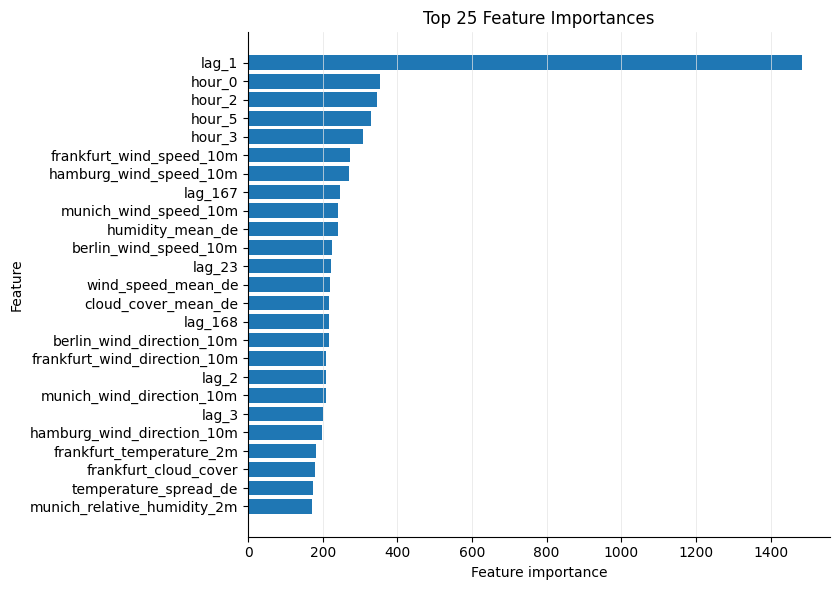

Top features:
lag_1                           1485
hour_0                           352
hour_2                           345
hour_5                           330
hour_3                           309
frankfurt_wind_speed_10m         274
hamburg_wind_speed_10m           271
lag_167                          247
munich_wind_speed_10m            241
humidity_mean_de                 240
berlin_wind_speed_10m            225
lag_23                           223
wind_speed_mean_de               218
cloud_cover_mean_de              217
lag_168                          217
berlin_wind_direction_10m        216
frankfurt_wind_direction_10m     209
lag_2                            208
munich_wind_direction_10m        208
lag_3                            200
hamburg_wind_direction_10m       199
frankfurt_temperature_2m         181
frankfurt_cloud_cover            178
temperature_spread_de            173
munich_relative_humidity_2m      172
2026-06-19 23:44:37,957 - task_safe_n_to_1 - INFO - Feature i

In [26]:
#| label: feature-importance-live
#| echo: true

import matplotlib.pyplot as plt
import pandas as pd

estimator = model.forecaster.estimator

# Prefer the forecaster's stored feature names.
# Fall back to LightGBM's feature_name_ if needed.
if hasattr(model.forecaster, "X_train_features_names_out_"):
    feature_names = list(model.forecaster.X_train_features_names_out_)
elif hasattr(estimator, "feature_name_"):
    feature_names = list(estimator.feature_name_)
else:
    raise AttributeError("Could not find fitted feature names.")

importances = estimator.feature_importances_

if len(feature_names) != len(importances):
    raise ValueError(
        f"Feature-name count ({len(feature_names)}) does not match "
        f"importance count ({len(importances)})."
    )

importance = pd.Series(
    importances,
    index=feature_names,
).sort_values(ascending=False)

top_n = 25
top_importance = importance.head(top_n).sort_values()

fig, ax = plt.subplots(figsize=(8.5, 6.0))

ax.barh(
    top_importance.index,
    top_importance.values,
)

ax.set_title(f"Top {top_n} Feature Importances")
ax.set_xlabel("Feature importance")
ax.set_ylabel("Feature")
ax.grid(True, axis="x", color="#E5E5E5", linewidth=0.5)

for s in ("top", "right"):
    ax.spines[s].set_visible(False)

fig.tight_layout()
plt.show()

print("Top features:")
print(importance.head(top_n).to_string())

logger.info("Feature importance plot generated.")
logger.info(f"Top feature: {importance.index[0]} = {importance.iloc[0]}")

## Forecast Curve

This section visualizes the generated 24-hour forecast.

It is a visual sanity check. It does not prove accuracy, but it helps detect unrealistic forecast shapes.

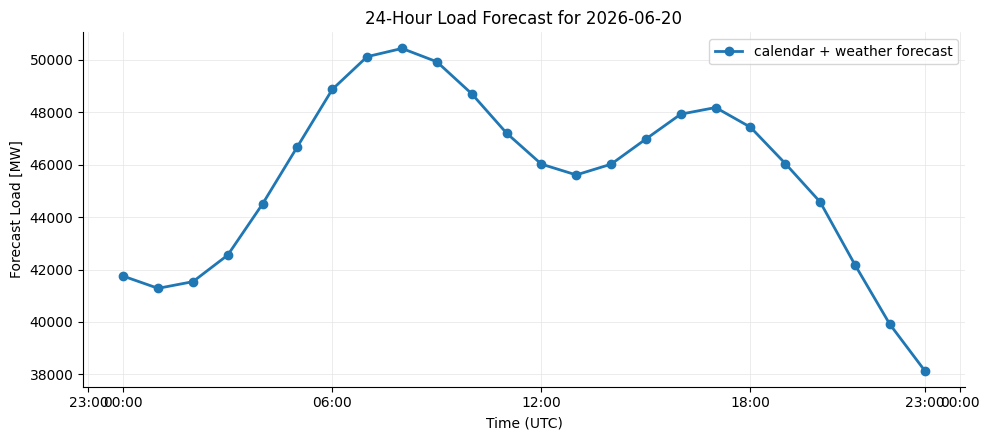

2026-06-19 23:44:38,533 - task_safe_n_to_1 - INFO - Forecast curve plot generated.


In [27]:
#| label: plot-forecast-live
#| echo: true

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df_plot = df_sub.copy()
df_plot = df_plot.set_index("timestamp_utc")

fig, ax = plt.subplots(figsize=(10, 4.5))

ax.plot(
    df_plot.index,
    df_plot["forecast_mw"],
    marker="o",
    linewidth=2.0,
    label="calendar + weather forecast",
)

ax.set_title(f"24-Hour Load Forecast for {TARGET_DATE}")
ax.set_xlabel("Time (UTC)")
ax.set_ylabel("Forecast Load [MW]")
ax.grid(True, color="#E5E5E5", linewidth=0.5)
ax.legend(loc="upper right")

ax.xaxis.set_major_locator(mdates.HourLocator(byhour=[0, 6, 12, 18, 23]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

for s in ("top", "right"):
    ax.spines[s].set_visible(False)

fig.tight_layout()
plt.show()

logger.info("Forecast curve plot generated.")

## Compare Forecast with Weekly Persistence

This section compares the generated forecast with a simple weekly-persistence baseline.

Weekly persistence means using the actual load from the same hour one week earlier.

This does not prove final accuracy, because actual load for the target day may not be available yet. It is a plausibility check.

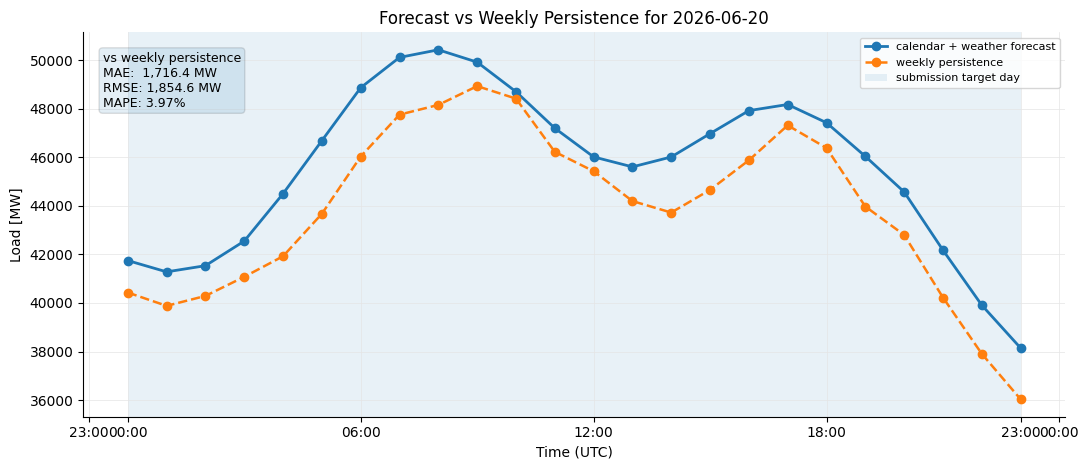

Forecast vs weekly persistence:
Mean difference:          1,716.4 MW
Mean absolute difference: 1,716.4 MW
RMSE:                     1,854.6 MW
MAPE:                     3.97%
Maximum absolute diff.:   3,012.5 MW
2026-06-19 23:44:38,999 - task_safe_n_to_1 - INFO - Weekly persistence comparison generated.
2026-06-19 23:44:39,000 - task_safe_n_to_1 - INFO - MAE vs weekly persistence: 1,716.4 MW
2026-06-19 23:44:39,001 - task_safe_n_to_1 - INFO - RMSE vs weekly persistence: 1,854.6 MW
2026-06-19 23:44:39,002 - task_safe_n_to_1 - INFO - MAPE vs weekly persistence: 3.97%


In [28]:
#| label: compare-weekly-persistence-live
#| echo: true

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

baseline_idx = target_hours - pd.Timedelta(days=7)

# Prefer raw observed load for the persistence baseline.
# Fall back to y_train_live only if necessary.
weekly_persistence = y_live_raw.reindex(baseline_idx)

if weekly_persistence.isna().any():
    missing_count = int(weekly_persistence.isna().sum())
    print(f"Raw weekly persistence has {missing_count} missing values.")
    print("Falling back to filled y_train_live for those timestamps.")

    weekly_persistence_filled = y_train_live.reindex(baseline_idx)

    if weekly_persistence_filled.isna().any():
        missing = weekly_persistence_filled[weekly_persistence_filled.isna()]
        raise ValueError(
            "Weekly persistence baseline is missing values even after fallback:\n"
            f"{missing}"
        )

    weekly_persistence = weekly_persistence.fillna(weekly_persistence_filled)

weekly_persistence.index = target_hours

forecast_values = submission["forecast_mw"].astype(float).values
persistence_values = weekly_persistence.astype(float).values

diff = forecast_values - persistence_values
abs_diff = np.abs(diff)

mae_vs_persistence = float(abs_diff.mean())
rmse_vs_persistence = float(np.sqrt(np.mean(diff ** 2)))
mape_vs_persistence = float(np.mean(abs_diff / persistence_values) * 100)

fig, ax = plt.subplots(figsize=(11, 4.8))

ax.plot(
    target_hours,
    forecast_values,
    marker="o",
    linewidth=2.0,
    label="calendar + weather forecast",
)

ax.plot(
    target_hours,
    persistence_values,
    marker="o",
    linestyle="--",
    linewidth=1.8,
    label="weekly persistence",
)

ax.axvspan(
    TOMORROW_UTC,
    LAST_TARGET,
    alpha=0.10,
    label="submission target day",
)

metric_text = (
    f"vs weekly persistence\n"
    f"MAE:  {mae_vs_persistence:,.1f} MW\n"
    f"RMSE: {rmse_vs_persistence:,.1f} MW\n"
    f"MAPE: {mape_vs_persistence:.2f}%"
)

ax.text(
    0.02,
    0.95,
    metric_text,
    transform=ax.transAxes,
    va="top",
    ha="left",
    fontsize=9,
    bbox=dict(boxstyle="round", alpha=0.12),
)

ax.set_title(f"Forecast vs Weekly Persistence for {TARGET_DATE}")
ax.set_xlabel("Time (UTC)")
ax.set_ylabel("Load [MW]")
ax.grid(True, color="#E5E5E5", linewidth=0.5)
ax.legend(loc="upper right", fontsize=8)

ax.xaxis.set_major_locator(mdates.HourLocator(byhour=[0, 6, 12, 18, 23]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

for s in ("top", "right"):
    ax.spines[s].set_visible(False)

fig.tight_layout()
plt.show()

print("Forecast vs weekly persistence:")
print(f"Mean difference:          {diff.mean():,.1f} MW")
print(f"Mean absolute difference: {mae_vs_persistence:,.1f} MW")
print(f"RMSE:                     {rmse_vs_persistence:,.1f} MW")
print(f"MAPE:                     {mape_vs_persistence:.2f}%")
print(f"Maximum absolute diff.:   {abs_diff.max():,.1f} MW")

logger.info("Weekly persistence comparison generated.")
logger.info(f"MAE vs weekly persistence: {mae_vs_persistence:,.1f} MW")
logger.info(f"RMSE vs weekly persistence: {rmse_vs_persistence:,.1f} MW")
logger.info(f"MAPE vs weekly persistence: {mape_vs_persistence:.2f}%")

## Recent Backtest with Calendar + Weather Features

This section tests the live v2 model on recent historical days.

For each backtest day:

1. train only on data before that day,
2. predict the next 24 hours,
3. compare the prediction with actual load,
4. calculate MAE and MAPE.

This gives a better estimate of model quality than visual inspection alone.

In [29]:
#| label: recent-backtest-live
#| echo: true

from sklearn.metrics import mean_absolute_error
from spotforecast2_safe.preprocessing import WeightFunction
from lightgbm import LGBMRegressor
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Backtest settings
# ------------------------------------------------------------
REQUESTED_BACKTEST_DAYS = 7
CANDIDATE_BACKTEST_DAYS = 90

HORIZON = 24
LAGS = 168

backtest_results = []
backtest_hourly_rows = []

# Last possible target day:
# We subtract one full day because the latest day may be incomplete.
last_possible_target = y_train_live.index.max().normalize() - pd.Timedelta(days=1)

# Search backwards over more days because the professor-masked period
# can invalidate recent days through the 168-hour input window.
target_days = [
    last_possible_target - pd.Timedelta(days=i)
    for i in range(CANDIDATE_BACKTEST_DAYS)
]

print("Candidate backtest target days:")
for d in target_days:
    print(d.date())

print()
print("Starting masked 7-day backtest...")

# ------------------------------------------------------------
# Main backtest loop
# ------------------------------------------------------------
for bt_target in target_days:

    if len(backtest_results) >= REQUESTED_BACKTEST_DAYS:
        print("Collected enough valid backtest days. Stopping search.")
        break

    bt_target_hours = pd.date_range(
        bt_target,
        periods=HORIZON,
        freq="h",
        tz="UTC",
    )

    # ------------------------------------------------------------
    # 1. Skip target days touching professor-masked faulty data
    # ------------------------------------------------------------
    bt_target_quality = target_quality_mask.reindex(bt_target_hours)

    if bt_target_quality.isna().any() or not bt_target_quality.all():
        print(
            f"Skipping {bt_target.date()} because target day touches "
            "professor-masked faulty data."
        )
        continue

    # ------------------------------------------------------------
    # 2. Skip days whose 168-hour input window touches faulty data
    # ------------------------------------------------------------
    bt_input_hours = pd.date_range(
        bt_target - pd.Timedelta(hours=LAGS),
        bt_target - pd.Timedelta(hours=1),
        freq="h",
        tz="UTC",
    )

    bt_input_quality = target_quality_mask.reindex(bt_input_hours)

    if bt_input_quality.isna().any() or not bt_input_quality.all():
        print(
            f"Skipping {bt_target.date()} because its {LAGS}-hour input window "
            "touches professor-masked faulty data."
        )
        continue

    # ------------------------------------------------------------
    # 3. Prepare training data
    # ------------------------------------------------------------
    bt_train_end = bt_target - pd.Timedelta(hours=1)
    bt_y_train = y_train_live.loc[:bt_train_end].copy()

    if len(bt_y_train) < LAGS:
        print(f"Skipping {bt_target.date()} because training data is too short.")
        continue

    bt_train_exog = exog.reindex(bt_y_train.index)

    if bt_train_exog.isna().any().any():
        raise ValueError(f"Training exog contains NaN for {bt_target.date()}.")

    # ------------------------------------------------------------
    # 4. Build prediction exogenous horizon
    # ------------------------------------------------------------
    bt_prediction_start = bt_y_train.index[-1] + pd.Timedelta(hours=1)
    bt_prediction_end = bt_target_hours[-1]

    bt_prediction_exog = exog.loc[bt_prediction_start:bt_prediction_end].copy()

    bt_horizon = int(
        (bt_prediction_end - bt_y_train.index[-1]) / pd.Timedelta(hours=1)
    )

    if len(bt_prediction_exog) != bt_horizon:
        raise ValueError(
            f"Prediction exog length mismatch for {bt_target.date()}: "
            f"{len(bt_prediction_exog)} rows vs horizon {bt_horizon}"
        )

    if bt_prediction_exog.isna().any().any():
        raise ValueError(f"Prediction exog contains NaN for {bt_target.date()}.")

    # ------------------------------------------------------------
    # 5. Create LightGBM recursive model
    # ------------------------------------------------------------
    bt_model = ForecasterRecursiveLGBM(
        iteration=0,
        lags=LAGS,
        periods=periods,
        country_code=COUNTRY,
        random_state=2026,
    )

    # Keep the same model parameters.
    bt_model.forecaster.estimator = LGBMRegressor(
    n_estimators=400,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=20,
    n_jobs=-1,
    verbose=-1,
    deterministic=True,
    force_col_wise=True,
    random_state=2026,
)

    # ------------------------------------------------------------
    # 6. Attach sliced WeightFunction
    # ------------------------------------------------------------
    bt_weights = weights.reindex(bt_y_train.index)

    if bt_weights.isna().any():
        raise ValueError(f"Backtest weights contain NaN for {bt_target.date()}.")

    bt_model.forecaster.weight_func = WeightFunction(bt_weights)

    # ------------------------------------------------------------
    # 7. Fit model
    # ------------------------------------------------------------
    print(f"Training backtest model for {bt_target.date()} ...")

    bt_model.fit(
        y=bt_y_train,
        exog=bt_train_exog,
    )

    # ------------------------------------------------------------
    # 8. Predict bridge horizon and slice target day
    # ------------------------------------------------------------
    bt_pred_full = bt_model.forecaster.predict(
        steps=bt_horizon,
        exog=bt_prediction_exog,
    )

    bt_pred_full.index = bt_prediction_exog.index
    bt_pred = bt_pred_full.reindex(bt_target_hours).copy()

    if bt_pred.isna().any():
        raise ValueError(f"Prediction contains NaN for {bt_target.date()}.")

    bt_actual = y_train_live.reindex(bt_target_hours)

    if bt_actual.isna().any():
        raise ValueError(f"Actual load contains NaN for {bt_target.date()}.")

    # ------------------------------------------------------------
    # 9. Model metrics
    # ------------------------------------------------------------
    model_errors = bt_pred.values - bt_actual.values

    for ts, actual_value, pred_value, err_value in zip(
        bt_target_hours,
        bt_actual.values,
        bt_pred.values,
        model_errors,
    ):
        backtest_hourly_rows.append({
            "target_date": bt_target.date().isoformat(),
            "timestamp_utc": ts,
            "hour": ts.hour,
            "actual_load_mw": float(actual_value),
            "prediction_mw": float(pred_value),
            "error_mw": float(err_value),
        })

    model_mae = float(mean_absolute_error(bt_actual.values, bt_pred.values))
    model_rmse = float(np.sqrt(np.mean(model_errors ** 2)))
    model_mape = float(np.mean(np.abs(model_errors / bt_actual.values)))
    model_bias = float(np.mean(model_errors))

    # ------------------------------------------------------------
    # 10. Weekly persistence baseline
    # ------------------------------------------------------------
    bt_persistence = y_train_live.shift(LAGS).reindex(bt_target_hours)

    if bt_persistence.isna().any():
        print(f"Skipping {bt_target.date()} because persistence baseline has NaN.")
        continue

    persistence_errors = bt_persistence.values - bt_actual.values

    persistence_mae = float(
        mean_absolute_error(bt_actual.values, bt_persistence.values)
    )
    persistence_rmse = float(np.sqrt(np.mean(persistence_errors ** 2)))
    persistence_mape = float(
        np.mean(np.abs(persistence_errors / bt_actual.values))
    )
    persistence_bias = float(np.mean(persistence_errors))

    affected_by_zero_weight = bool(
        (weights.reindex(bt_target_hours).fillna(0) == 0).any()
    )

    # ------------------------------------------------------------
    # 11. Store one valid backtest day
    # ------------------------------------------------------------
    backtest_results.append({
        "target_date": bt_target.date().isoformat(),
        "model_mae_mw": model_mae,
        "model_rmse_mw": model_rmse,
        "model_mape": model_mape,
        "model_bias_mw": model_bias,
        "persistence_mae_mw": persistence_mae,
        "persistence_rmse_mw": persistence_rmse,
        "persistence_mape": persistence_mape,
        "persistence_bias_mw": persistence_bias,
        "model_better_mae": model_mae < persistence_mae,
        "model_better_rmse": model_rmse < persistence_rmse,
        "model_better_mape": model_mape < persistence_mape,
        "affected_by_zero_weight": affected_by_zero_weight,
    })

    print(
        f"Collected valid backtest days: "
        f"{len(backtest_results)}/{REQUESTED_BACKTEST_DAYS}"
    )

# ------------------------------------------------------------
# 12. Convert results to DataFrame
# ------------------------------------------------------------
bt_results = (
    pd.DataFrame(backtest_results)
    .sort_values("target_date")
    .reset_index(drop=True)
)
bt_hourly_results = (
    pd.DataFrame(backtest_hourly_rows)
    .sort_values("timestamp_utc")
    .reset_index(drop=True)
)

print()
print("Hourly backtest results:")
print(bt_hourly_results.head())
print(bt_hourly_results.tail())
print("Hourly rows:", len(bt_hourly_results))

print()
print("Backtest results:")
print(bt_results)

if len(bt_results) == 0:
    raise ValueError(
        "No valid backtest days remained after professor quality masking. "
        "Increase CANDIDATE_BACKTEST_DAYS to 120 or check target_quality_mask alignment."
    )

if len(bt_results) < REQUESTED_BACKTEST_DAYS:
    print()
    print(
        f"Warning: only {len(bt_results)} valid backtest days were found, "
        f"but {REQUESTED_BACKTEST_DAYS} were requested."
    )

# ------------------------------------------------------------
# 13. Print summary
# ------------------------------------------------------------
print()
print("Valid backtest summary:")
print(f"Model mean MAE:        {bt_results['model_mae_mw'].mean():,.1f} MW")
print(f"Persistence mean MAE:  {bt_results['persistence_mae_mw'].mean():,.1f} MW")
print(f"Model mean RMSE:       {bt_results['model_rmse_mw'].mean():,.1f} MW")
print(f"Persistence mean RMSE: {bt_results['persistence_rmse_mw'].mean():,.1f} MW")
print(f"Model mean MAPE:       {bt_results['model_mape'].mean():.2%}")
print(f"Persistence mean MAPE: {bt_results['persistence_mape'].mean():.2%}")
print(f"Model mean bias:       {bt_results['model_bias_mw'].mean():,.1f} MW")
print(f"Persistence mean bias: {bt_results['persistence_bias_mw'].mean():,.1f} MW")

print()
print("Days better than persistence:")
print(f"MAE:  {int(bt_results['model_better_mae'].sum())}/{len(bt_results)}")
print(f"RMSE: {int(bt_results['model_better_rmse'].sum())}/{len(bt_results)}")
print(f"MAPE: {int(bt_results['model_better_mape'].sum())}/{len(bt_results)}")

# ------------------------------------------------------------
# 14. Clean-only summary
# ------------------------------------------------------------
clean_bt_results = bt_results[~bt_results["affected_by_zero_weight"]].copy()

print()
print("Clean backtest days only:")
print(clean_bt_results)

if len(clean_bt_results) > 0:
    print()
    print("Clean backtest summary:")
    print(f"Clean model mean MAE:        {clean_bt_results['model_mae_mw'].mean():,.1f} MW")
    print(f"Clean persistence mean MAE:  {clean_bt_results['persistence_mae_mw'].mean():,.1f} MW")
    print(f"Clean model mean RMSE:       {clean_bt_results['model_rmse_mw'].mean():,.1f} MW")
    print(f"Clean persistence mean RMSE: {clean_bt_results['persistence_rmse_mw'].mean():,.1f} MW")
    print(f"Clean model mean MAPE:       {clean_bt_results['model_mape'].mean():.2%}")
    print(f"Clean persistence mean MAPE: {clean_bt_results['persistence_mape'].mean():.2%}")
    print(f"Clean model mean bias:       {clean_bt_results['model_bias_mw'].mean():,.1f} MW")
    print(f"Clean persistence mean bias: {clean_bt_results['persistence_bias_mw'].mean():,.1f} MW")

# ------------------------------------------------------------
# 15. Logging
# ------------------------------------------------------------
logger.info("Recent backtest completed.")
logger.info(f"Valid backtest days: {len(bt_results)}")
logger.info(f"Model mean MAE: {bt_results['model_mae_mw'].mean():,.1f} MW")
logger.info(f"Persistence mean MAE: {bt_results['persistence_mae_mw'].mean():,.1f} MW")

Candidate backtest target days:
2026-06-18
2026-06-17
2026-06-16
2026-06-15
2026-06-14
2026-06-13
2026-06-12
2026-06-11
2026-06-10
2026-06-09
2026-06-08
2026-06-07
2026-06-06
2026-06-05
2026-06-04
2026-06-03
2026-06-02
2026-06-01
2026-05-31
2026-05-30
2026-05-29
2026-05-28
2026-05-27
2026-05-26
2026-05-25
2026-05-24
2026-05-23
2026-05-22
2026-05-21
2026-05-20
2026-05-19
2026-05-18
2026-05-17
2026-05-16
2026-05-15
2026-05-14
2026-05-13
2026-05-12
2026-05-11
2026-05-10
2026-05-09
2026-05-08
2026-05-07
2026-05-06
2026-05-05
2026-05-04
2026-05-03
2026-05-02
2026-05-01
2026-04-30
2026-04-29
2026-04-28
2026-04-27
2026-04-26
2026-04-25
2026-04-24
2026-04-23
2026-04-22
2026-04-21
2026-04-20
2026-04-19
2026-04-18
2026-04-17
2026-04-16
2026-04-15
2026-04-14
2026-04-13
2026-04-12
2026-04-11
2026-04-10
2026-04-09
2026-04-08
2026-04-07
2026-04-06
2026-04-05
2026-04-04
2026-04-03
2026-04-02
2026-04-01
2026-03-31
2026-03-30
2026-03-29
2026-03-28
2026-03-27
2026-03-26
2026-03-25
2026-03-24
2026-03-23


In [30]:
#| label: check-hourly-backtest-results
#| echo: true

if "bt_hourly_results" not in globals():
    raise ValueError("bt_hourly_results does not exist. The hourly storage block was not added or not executed.")

print("bt_hourly_results exists.")
print("Rows:", len(bt_hourly_results))
print("Columns:", list(bt_hourly_results.columns))
print()
print(bt_hourly_results.head())
print()
print(bt_hourly_results.tail())

expected_rows = len(bt_results) * 24

print()
print("Expected hourly rows:", expected_rows)

if len(bt_hourly_results) != expected_rows:
    raise ValueError(
        f"Unexpected hourly row count: {len(bt_hourly_results)} instead of {expected_rows}."
    )

print("Hourly backtest table looks correct.")

bt_hourly_results exists.
Rows: 168
Columns: ['target_date', 'timestamp_utc', 'hour', 'actual_load_mw', 'prediction_mw', 'error_mw']

  target_date             timestamp_utc  hour  actual_load_mw  prediction_mw  \
0  2026-06-02 2026-06-02 00:00:00+00:00     0    43856.188483   43710.056435   
1  2026-06-02 2026-06-02 01:00:00+00:00     1    44506.008435   43293.069065   
2  2026-06-02 2026-06-02 02:00:00+00:00     2    45242.669760   43847.232445   
3  2026-06-02 2026-06-02 03:00:00+00:00     3    47719.433077   46406.005437   
4  2026-06-02 2026-06-02 04:00:00+00:00     4    53632.268760   52368.457777   

      error_mw  
0  -146.132047  
1 -1212.939370  
2 -1395.437315  
3 -1313.427640  
4 -1263.810983  

    target_date             timestamp_utc  hour  actual_load_mw  \
163  2026-06-18 2026-06-18 19:00:00+00:00    19    55256.626045   
164  2026-06-18 2026-06-18 20:00:00+00:00    20    53219.670250   
165  2026-06-18 2026-06-18 21:00:00+00:00    21    49586.313103   
166  2026-06-1

In [31]:
#| label: backtest-bias-check
#| echo: true

print("Backtest bias check:")

# Bias means: forecast - actual.
# Positive bias = prediction is too high.
# Negative bias = prediction is too low.

required_cols = ["model_bias_mw", "persistence_bias_mw"]
missing_cols = [c for c in required_cols if c not in bt_results.columns]

if missing_cols:
    print("Missing columns:", missing_cols)
    print("Run the updated recent-backtest-live cell first.")
else:
    model_mean_bias = bt_results["model_bias_mw"].mean()
    model_median_bias = bt_results["model_bias_mw"].median()

    persistence_mean_bias = bt_results["persistence_bias_mw"].mean()
    persistence_median_bias = bt_results["persistence_bias_mw"].median()

    print(f"Model mean bias:          {model_mean_bias:,.1f} MW")
    print(f"Model median bias:        {model_median_bias:,.1f} MW")
    print(f"Persistence mean bias:    {persistence_mean_bias:,.1f} MW")
    print(f"Persistence median bias:  {persistence_median_bias:,.1f} MW")

    print()

    if model_mean_bias > 0:
        print("Model is usually too high.")
    elif model_mean_bias < 0:
        print("Model is usually too low.")
    else:
        print("Model has almost no average bias.")

    print()
    print("Daily model bias:")
    print(bt_results[["target_date", "model_bias_mw", "model_mae_mw", "model_mape"]])


Backtest bias check:
Model mean bias:          -89.8 MW
Model median bias:        -171.6 MW
Persistence mean bias:    -547.4 MW
Persistence median bias:  46.2 MW

Model is usually too low.

Daily model bias:
  target_date  model_bias_mw  model_mae_mw  model_mape
0  2026-06-02    -822.867641   1174.320451    0.021804
1  2026-06-13    -171.559442    932.487581    0.021524
2  2026-06-14     666.182149    746.971150    0.017704
3  2026-06-15     502.095566    892.683917    0.017188
4  2026-06-16     200.239185    733.825235    0.013928
5  2026-06-17    -474.446185   1415.992663    0.026150
6  2026-06-18    -528.312782    895.267944    0.016988


## Backtest Error Plot

This plot shows the daily MAE values for the recent backtest.

It compares the calendar + weather model with the weekly-persistence baseline.

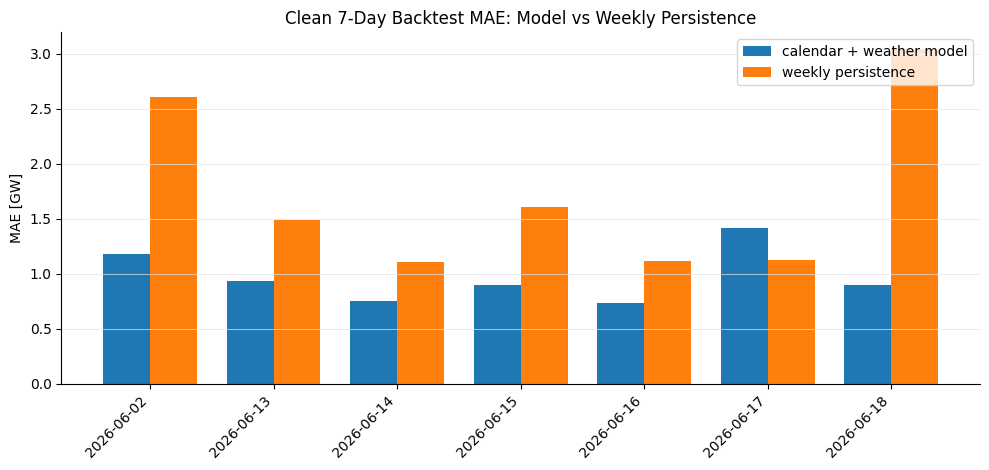

2026-06-19 23:47:31,309 - task_safe_n_to_1 - INFO - Backtest error comparison plot generated.


In [32]:
#| label: plot-backtest-errors-live
#| echo: true

fig, ax = plt.subplots(figsize=(10, 4.8))

x = np.arange(len(bt_results))
width = 0.38

ax.bar(
    x - width / 2,
    bt_results["model_mae_mw"] / 1000,
    width,
    label="calendar + weather model",
)

ax.bar(
    x + width / 2,
    bt_results["persistence_mae_mw"] / 1000,
    width,
    label="weekly persistence",
)

ax.set_xticks(x)
ax.set_xticklabels(bt_results["target_date"], rotation=45, ha="right")
ax.set_ylabel("MAE [GW]")
ax.set_title("Clean 7-Day Backtest MAE: Model vs Weekly Persistence")
ax.grid(True, axis="y", color="#E5E5E5", linewidth=0.5)
ax.legend(loc="upper right")

for s in ("top", "right"):
    ax.spines[s].set_visible(False)

fig.tight_layout()
plt.show()

logger.info("Backtest error comparison plot generated.")

## Backtest Error Distribution

This histogram shows how the model MAE values are distributed across recent backtest days.

It helps identify the typical error and the worst tested day.

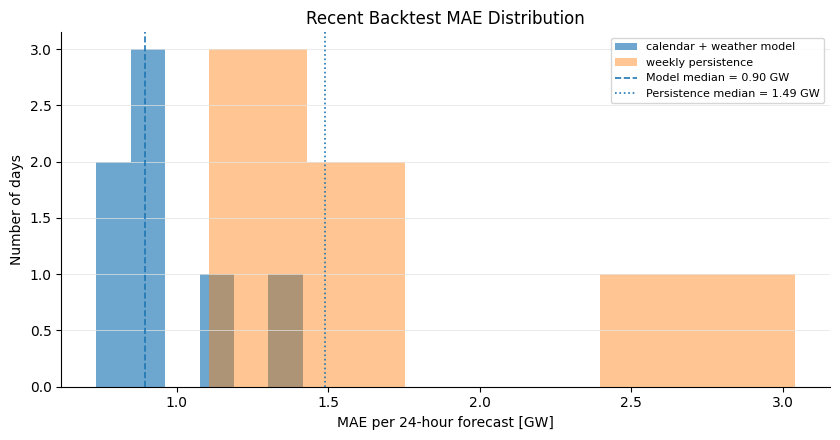

Backtest MAE distribution:
Model median MAE:       0.90 GW
Persistence median MAE: 1.49 GW
Model maximum MAE:      1.42 GW
Persistence maximum MAE:3.04 GW
2026-06-19 23:47:31,686 - task_safe_n_to_1 - INFO - Backtest MAE distribution plot generated.
2026-06-19 23:47:31,689 - task_safe_n_to_1 - INFO - Backtest model median MAE: 0.90 GW
2026-06-19 23:47:31,692 - task_safe_n_to_1 - INFO - Backtest persistence median MAE: 1.49 GW


In [33]:
#| label: plot-backtest-distribution-live
#| echo: true

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8.5, 4.5))

model_mae_gw = bt_results["model_mae_mw"] / 1000
persistence_mae_gw = bt_results["persistence_mae_mw"] / 1000

ax.hist(
    model_mae_gw,
    bins=6,
    alpha=0.65,
    label="calendar + weather model",
)

ax.hist(
    persistence_mae_gw,
    bins=6,
    alpha=0.45,
    label="weekly persistence",
)

model_median = model_mae_gw.median()
persistence_median = persistence_mae_gw.median()

ax.axvline(
    model_median,
    linestyle="--",
    linewidth=1.2,
    label=f"Model median = {model_median:.2f} GW",
)

ax.axvline(
    persistence_median,
    linestyle=":",
    linewidth=1.2,
    label=f"Persistence median = {persistence_median:.2f} GW",
)

ax.set_title("Recent Backtest MAE Distribution")
ax.set_xlabel("MAE per 24-hour forecast [GW]")
ax.set_ylabel("Number of days")
ax.grid(True, axis="y", color="#E5E5E5", linewidth=0.5)
ax.legend(loc="upper right", fontsize=8)

for s in ("top", "right"):
    ax.spines[s].set_visible(False)

fig.tight_layout()
plt.show()

print("Backtest MAE distribution:")
print(f"Model median MAE:       {model_median:.2f} GW")
print(f"Persistence median MAE: {persistence_median:.2f} GW")
print(f"Model maximum MAE:      {model_mae_gw.max():.2f} GW")
print(f"Persistence maximum MAE:{persistence_mae_gw.max():.2f} GW")

logger.info("Backtest MAE distribution plot generated.")
logger.info(f"Backtest model median MAE: {model_median:.2f} GW")
logger.info(f"Backtest persistence median MAE: {persistence_median:.2f} GW")

## Persist Provenance

This section saves a provenance file for the live v2 run.

The provenance file records:

- target date,
- team id,
- training range,
- model settings,
- number of features,
- weather location,
- output CSV path,
- backtest summary.

This makes the run reproducible and easier to audit.

In [34]:
#| label: persist-provenance-live
#| echo: true

import json
import platform
import sys

actual_lags = model.forecaster.lags

provenance = {
    "schema_version": "1.0.0",
    "pipeline": "live_preprocessing_v2",
    "team_id": TEAM_ID,
    "target_date": TARGET_DATE,
    "country": COUNTRY,

    "now_utc": str(NOW_UTC),
    "last_full_actual_hour": str(LAST_FULL_HOUR),
    "first_prediction_hour": str(FIRST_PRED),
    "last_target_hour": str(LAST_TARGET),
    "live_n_steps": int(LIVE_N_STEPS),

    "training_index_from": str(y_train_live.index.min()),
    "training_index_to": str(y_train_live.index.max()),
    "training_rows": int(len(y_train_live)),

    "model_name": "lgbm_calendar_multicity_weather_live",
    "estimator": "ForecasterRecursiveLGBM",
    "estimator_config": {
    "type": "LGBMRegressor",
    "n_estimators": 400,
    "learning_rate": 0.05,
    "num_leaves": 63,
    "min_child_samples": 20,
    "deterministic": True,
    "force_col_wise": True,
    "random_state": 2026,
},
    "lags": actual_lags.tolist() if hasattr(actual_lags, "tolist") else list(actual_lags),
    "number_of_lags": int(model.forecaster.lags.size),
    "seed": int(model.random_state),

    "weight_function_attached": bool(model.forecaster.weight_func is not None),
    "outlier_contamination": 0.005,
    "marked_outlier_rows": int(n_marked),
    "zero_weight_rows": int((weights == 0).sum()),
    "zero_weight_share": float((weights == 0).mean()),
    "annotation_window_size": int(WINDOW_SIZE),

    "calendar_feature_count": int(exog_cal.shape[1]),
    "weather_feature_count": int(weather.shape[1]),
    "exog_column_count": int(exog.shape[1]),
    "train_exog_shape": list(train_exog.shape),
    "prediction_exog_shape": list(prediction_exog.shape),

    "weather_locations": WEATHER_LOCATIONS,
    "weather_columns": WEATHER_COLUMNS,

    "submission_path": str(out),
    "forecast_rows": int(len(submission)),
    "forecast_min_mw": float(submission["forecast_mw"].min()),
    "forecast_max_mw": float(submission["forecast_mw"].max()),

    "blend_applied": False,
    "blend_type": "none",
    "forecast_source": "pure_model_prediction",
    "entsoe_forecast_used_for_submission": False,
    "weekly_persistence_used_for_submission": False,

    "backtest_days": int(len(bt_results)),
    "backtest_model_mean_mae_mw": float(bt_results["model_mae_mw"].mean()),
    "backtest_model_mean_rmse_mw": float(bt_results["model_rmse_mw"].mean()),
    "backtest_model_mean_mape": float(bt_results["model_mape"].mean()),
    "backtest_persistence_mean_mae_mw": float(bt_results["persistence_mae_mw"].mean()),
    "backtest_persistence_mean_rmse_mw": float(bt_results["persistence_rmse_mw"].mean()),
    "backtest_persistence_mean_mape": float(bt_results["persistence_mape"].mean()),
    "backtest_model_median_mae_gw": float((bt_results["model_mae_mw"] / 1000).median()),
    "backtest_model_max_mae_gw": float((bt_results["model_mae_mw"] / 1000).max()),

    "python_version": sys.version,
    "platform": platform.platform(),
}

provenance_path = shared / f"provenance_live_{TEAM_ID}_{TARGET_DATE}.json"

with open(provenance_path, "w", encoding="utf-8") as f:
    json.dump(provenance, f, indent=2, ensure_ascii=False)

logger.info(f"Live provenance persisted: {provenance_path}")

print(f"Provenance saved to: {provenance_path}")
print()
print(json.dumps(provenance, indent=2, ensure_ascii=False))

2026-06-19 23:47:31,741 - task_safe_n_to_1 - INFO - Live provenance persisted: _cache\shared\provenance_live_neura_2026-06-20.json
Provenance saved to: _cache\shared\provenance_live_neura_2026-06-20.json

{
  "schema_version": "1.0.0",
  "pipeline": "live_preprocessing_v2",
  "team_id": "neura",
  "target_date": "2026-06-20",
  "country": "DE",
  "now_utc": "2026-06-19 21:39:00.686483+00:00",
  "last_full_actual_hour": "2026-06-19 20:00:00+00:00",
  "first_prediction_hour": "2026-06-19 21:00:00+00:00",
  "last_target_hour": "2026-06-20 23:00:00+00:00",
  "live_n_steps": 27,
  "training_index_from": "2024-01-01 00:00:00+00:00",
  "training_index_to": "2026-06-19 20:00:00+00:00",
  "training_rows": 21621,
  "model_name": "lgbm_calendar_multicity_weather_live",
  "estimator": "ForecasterRecursiveLGBM",
  "estimator_config": {
    "type": "LGBMRegressor",
    "n_estimators": 400,
    "learning_rate": 0.05,
    "num_leaves": 63,
    "min_child_samples": 20,
    "deterministic": true,
    "f

## Log Summary

This section prints the path of the audit log and shows the first few log entries.

The log file can be used later to inspect the run.

In [35]:
#| label: log-summary-live
#| echo: true

from pathlib import Path

print(f"Log file: {log_path}")

if log_path and Path(log_path).exists():
    log_file = Path(log_path)
    lines = log_file.read_text(encoding="utf-8").splitlines()

    print(f"Log lines: {len(lines)}")
    print(f"Log path: {log_file.resolve()}")

    if len(lines) == 0:
        print("Log file exists but is empty.")
    else:
        print()
        print("First five entries:")
        for line in lines[:5]:
            print(line)

        print()
        print("Last ten entries:")
        for line in lines[-10:]:
            print(line)
else:
    print("No persistent log file found.")

Log file: _cache\logs\task_safe_n_to_1_20260619_233900.log
Log lines: 90
Log path: D:\AIT\ddmo-sose-26\venv\_cache\logs\task_safe_n_to_1_20260619_233900.log

First five entries:
{"schema_version":"1.0.0","timestamp_utc":"2026-06-19T21:39:00.653131Z","logger":"task_safe_n_to_1","level":"INFO","event":"audit_log_init","message":"Persistent logging initialized at: _cache\\logs\\task_safe_n_to_1_20260619_233900.log"}
{"schema_version":"1.0.0","timestamp_utc":"2026-06-19T21:39:00.655589Z","logger":"task_safe_n_to_1","level":"INFO","event":"log","message":"Live v2 load-forecasting pipeline starts."}
{"schema_version":"1.0.0","timestamp_utc":"2026-06-19T21:39:00.688908Z","logger":"task_safe_n_to_1","level":"INFO","event":"log","message":"Repo root: D:\\AIT\\challenge-leaderboard"}
{"schema_version":"1.0.0","timestamp_utc":"2026-06-19T21:39:00.693071Z","logger":"task_safe_n_to_1","level":"INFO","event":"log","message":"Data home: d:\\AIT\\ddmo-sose-26\\venv\\_cache\\spotforecast2_data"}
{"sche

## Persist Trained Model

This section saves the trained model object.

The saved model can be reloaded later for inspection or debugging.

In [36]:
#| label: persist-model-live
#| echo: true

import pickle

model_path = shared / f"forecaster_live_{TEAM_ID}_{TARGET_DATE}.pkl"

with open(model_path, "wb") as f:
    pickle.dump(model, f)

logger.info(f"Trained live model persisted: {model_path}")
logger.info(f"Model target date: {TARGET_DATE}")
logger.info(f"Model lags: {model.forecaster.lags.size}")
logger.info(f"Weight function attached: {model.forecaster.weight_func is not None}")

print(f"Model saved to: {model_path}")
print("Target date:", TARGET_DATE)
print("Lags:", model.forecaster.lags.size)
print("Weight function attached:", model.forecaster.weight_func is not None)

2026-06-19 23:47:32,048 - task_safe_n_to_1 - INFO - Trained live model persisted: _cache\shared\forecaster_live_neura_2026-06-20.pkl
2026-06-19 23:47:32,051 - task_safe_n_to_1 - INFO - Model target date: 2026-06-20
2026-06-19 23:47:32,054 - task_safe_n_to_1 - INFO - Model lags: 168
2026-06-19 23:47:32,057 - task_safe_n_to_1 - INFO - Weight function attached: True
Model saved to: _cache\shared\forecaster_live_neura_2026-06-20.pkl
Target date: 2026-06-20
Lags: 168
Weight function attached: True


In [37]:
#| label: quick-backtest-summary
#| echo: true

print("Quick backtest summary:")
print(f"Model mean MAE:        {bt_results['model_mae_mw'].mean():,.1f} MW")
print(f"Persistence mean MAE:  {bt_results['persistence_mae_mw'].mean():,.1f} MW")
print(f"Model mean RMSE:       {bt_results['model_rmse_mw'].mean():,.1f} MW")
print(f"Persistence mean RMSE: {bt_results['persistence_rmse_mw'].mean():,.1f} MW")
print(f"Model mean MAPE:       {bt_results['model_mape'].mean():.2%}")
print(f"Persistence mean MAPE: {bt_results['persistence_mape'].mean():.2%}")

print()
print("Days better than persistence by MAE:")
print(f"{int(bt_results['model_better_mae'].sum())}/{len(bt_results)}")

Quick backtest summary:
Model mean MAE:        970.2 MW
Persistence mean MAE:  1,727.9 MW
Model mean RMSE:       1,174.4 MW
Persistence mean RMSE: 2,179.6 MW
Model mean MAPE:       1.93%
Persistence mean MAPE: 3.42%

Days better than persistence by MAE:
6/7


Forecast vs Actual test day:
TEST_DAY: 2026-06-18
first: 2026-06-18 00:00:00+00:00
last:  2026-06-18 23:00:00+00:00

Forecast vs Actual metrics:
MAE:  895.3 MW
RMSE: 1,117.6 MW
MAPE: 1.70%

                           actual_load_mw   forecast_mw     error_mw  \
2026-06-18 00:00:00+00:00    43985.132055  44192.355721   207.223666   
2026-06-18 01:00:00+00:00    44119.848200  44300.926478   181.078278   
2026-06-18 02:00:00+00:00    44977.682445  45342.300850   364.618405   
2026-06-18 03:00:00+00:00    46788.884923  48204.403584  1415.518661   
2026-06-18 04:00:00+00:00    53333.015315  54524.540794  1191.525479   
2026-06-18 05:00:00+00:00    58332.429720  57690.482213  -641.947507   
2026-06-18 06:00:00+00:00    59894.378668  59705.554495  -188.824172   
2026-06-18 07:00:00+00:00    58769.640462  59097.680527   328.040065   
2026-06-18 08:00:00+00:00    58088.702932  58478.698826   389.995893   
2026-06-18 09:00:00+00:00    58619.944593  58299.389621  -320.554972   
2026-06-18 10:00:0

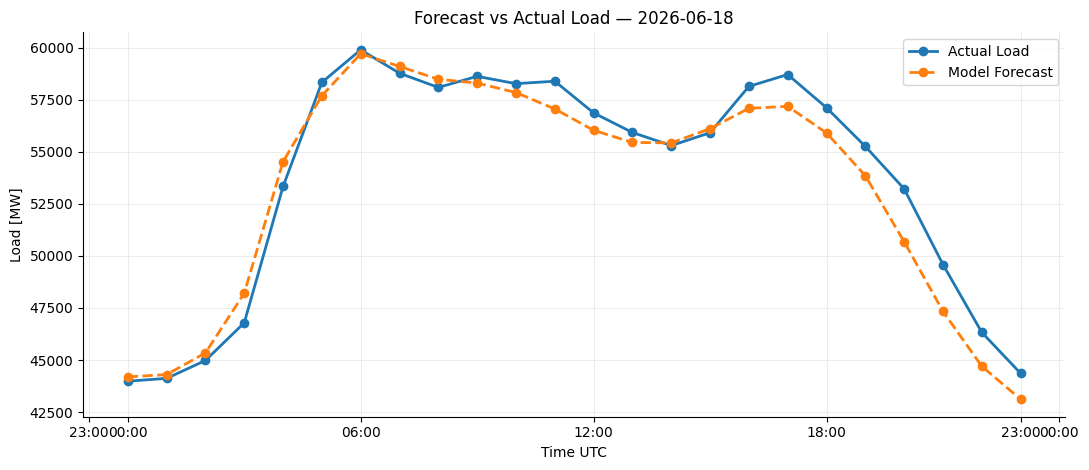

2026-06-19 23:48:14,430 - task_safe_n_to_1 - INFO - Forecast vs actual load plot generated for 2026-06-18: MAE=895.3 MW, RMSE=1,117.6 MW, MAPE=1.70%


In [38]:
#| label: plot-two-days-before-forecast-vs-actual
#| echo: true

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error

from spotforecast2_safe import ForecasterRecursiveLGBM
from spotforecast2_safe.preprocessing import WeightFunction
from lightgbm import LGBMRegressor

# Use a day where actual load is already available.
TEST_DAY = (TOMORROW_UTC - pd.Timedelta(days=2)).normalize()
test_hours = pd.date_range(TEST_DAY, periods=24, freq="h", tz="UTC")

print("Forecast vs Actual test day:")
print("TEST_DAY:", TEST_DAY.date())
print("first:", test_hours[0])
print("last: ", test_hours[-1])

# Actual load directly from ENTSO-E raw data.
actual_col = next(
    c for c in df_raw.columns
    if "Actual" in c and "Load" in c
)

actual_raw = df_raw[actual_col].astype(float).copy()
actual_raw.index = pd.to_datetime(actual_raw.index, utc=True)
actual_raw = actual_raw.sort_index()

# Germany load is often 15-minute resolution. Convert to hourly mean.
actual_hourly = actual_raw.resample("h").mean()

actual = actual_hourly.reindex(test_hours)

if actual.isna().any():
    print("Missing actual values:")
    print(actual[actual.isna()])
    raise ValueError("Actual load is incomplete for this test day.")

# Train the same model structure only up to the hour before TEST_DAY.
test_train_end = TEST_DAY - pd.Timedelta(hours=1)
test_y_train = y_train_live.loc[:test_train_end]
test_train_exog = exog.loc[test_y_train.index]
test_prediction_exog = exog.loc[test_hours]

if len(test_prediction_exog) != 24:
    raise ValueError(f"Expected 24 prediction exog rows, got {len(test_prediction_exog)}.")

if test_train_exog.isna().any().any():
    raise ValueError("Training exog contains NaN.")

if test_prediction_exog.isna().any().any():
    raise ValueError("Prediction exog contains NaN.")

# Same final model structure as live forecast.
test_model = ForecasterRecursiveLGBM(
    iteration=0,
    lags=168,
    periods=periods,
    country_code=COUNTRY,
    random_state=2026,
)

# Keep this block only if your final model uses the richer deterministic estimator.
test_model.forecaster.estimator = LGBMRegressor(
    n_estimators=400,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=20,
    n_jobs=-1,
    verbose=-1,
    deterministic=True,
    force_col_wise=True,
    random_state=2026,
)

test_weights = weights.reindex(test_y_train.index)

if test_weights.isna().any():
    raise ValueError("Training weights contain NaN for the historical test.")

test_model.forecaster.weight_func = WeightFunction(test_weights)

test_model.fit(
    y=test_y_train,
    exog=test_train_exog,
)

forecast = test_model.forecaster.predict(
    steps=24,
    exog=test_prediction_exog,
)

forecast.index = test_hours

comparison = pd.DataFrame({
    "actual_load_mw": actual.values,
    "forecast_mw": forecast.values,
}, index=test_hours)

comparison["error_mw"] = comparison["forecast_mw"] - comparison["actual_load_mw"]
comparison["abs_error_mw"] = comparison["error_mw"].abs()

mae = float(mean_absolute_error(comparison["actual_load_mw"], comparison["forecast_mw"]))
rmse = float(np.sqrt(np.mean(comparison["error_mw"] ** 2)))
mape = float(np.mean(comparison["abs_error_mw"] / comparison["actual_load_mw"]) * 100)

print()
print("Forecast vs Actual metrics:")
print(f"MAE:  {mae:,.1f} MW")
print(f"RMSE: {rmse:,.1f} MW")
print(f"MAPE: {mape:.2f}%")

print()
print(comparison)

fig, ax = plt.subplots(figsize=(11, 4.8))

ax.plot(
    comparison.index,
    comparison["actual_load_mw"],
    marker="o",
    linewidth=2.0,
    label="Actual Load",
)

ax.plot(
    comparison.index,
    comparison["forecast_mw"],
    marker="o",
    linestyle="--",
    linewidth=2.0,
    label="Model Forecast",
)

ax.set_title(f"Forecast vs Actual Load — {TEST_DAY.date()}")
ax.set_xlabel("Time UTC")
ax.set_ylabel("Load [MW]")
ax.grid(True, color="#E5E5E5", linewidth=0.5)
ax.legend(loc="upper right")

ax.xaxis.set_major_locator(mdates.HourLocator(byhour=[0, 6, 12, 18, 23]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

for s in ("top", "right"):
    ax.spines[s].set_visible(False)

fig.tight_layout()
plt.show()

logger.info(
    f"Forecast vs actual load plot generated for {TEST_DAY.date()}: "
    f"MAE={mae:,.1f} MW, RMSE={rmse:,.1f} MW, MAPE={mape:.2f}%"
)